# 2D FDTD Electromagnetic Solver — Complete Optimization Pipeline

**Authors:** Vraj Patel (241110080), Vardhman Dwivedi (241060033)  
**Course:** IDC 606 — Fast Computational Hydrodynamics, IIT Kanpur

### 9 Versions: Loops → NumPy → Warp v1 → Warp v2 → Warp Pure → CuPy → CuPy Pure → CUDA C → CUDA C Pure

## Install Warp & Verify GPU

In [28]:
!pip install warp-lang -q
!nvidia-smi

Sat Mar 28 10:03:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P0             31W /  250W |     293MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Imports & Warp Initialization

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warp as wp

wp.init()

device = "cuda" if wp.is_cuda_available() else "cpu"
print(f"Warp device: {device}")
if device == "cpu":
    print("WARNING: No GPU detected! Go to Runtime > Change runtime type > GPU")

Warp device: cuda


## Physical Constants, Grid Parameters & Obstacle Setup

In [30]:
# Physical constants
c0   = 3.0e8
mu0  = 4.0e-7 * np.pi
eps0 = 1.0 / (mu0 * c0**2)

# Grid parameters
Nx = 200
Ny = 200
dx = 1e-3
dy = 1e-3

# CFL stability
courant_number = 0.99
dt = courant_number / (c0 * np.sqrt(1.0/dx**2 + 1.0/dy**2))
n_steps = 400

# Source parameters (Gaussian pulse)
src_x  = Nx // 2
src_y  = Ny // 2
spread = 12.0 * dt
t0     = 3.0 * spread

# Pre-compute update coefficients
coeff_hx_val = float(dt / (mu0 * dy))
coeff_hy_val = float(dt / (mu0 * dx))
coeff_ez_val = float(dt / eps0)

print(f"Grid         : {Nx} x {Ny}  ({Nx*Ny:,} cells)")
print(f"Cell size    : dx = {dx*1e3:.2f} mm,  dy = {dy*1e3:.2f} mm")
print(f"Time step    : dt = {dt:.4e} s  (Courant # = {courant_number})")
print(f"Time steps   : {n_steps}")
print(f"Source       : ({src_x}, {src_y})")
print(f"GPU memory   : {3 * Nx * Ny * 4 / 1024:.1f} KB for field arrays")

# ─── PEC Obstacle (arbitrary shape inside the cavity) ───
# Create a boolean mask: True = obstacle cell (Ez forced to 0)
# The obstacle acts as a perfect reflector, same as the PEC walls.
# Change this function to define any shape you want.

def make_obstacle_mask(Nx, Ny, shape="circle", **kwargs):
    """Generate a boolean mask for a PEC obstacle.
    
    Supported shapes:
      'circle'    — center=(cx,cy), radius=r  (in grid cells)
      'rectangle' — x0, y0, x1, y1            (in grid cells)
      'polygon'   — vertices=[(x,y), ...]     (in grid cells)
      'none'      — no obstacle
    """
    mask = np.zeros((Nx, Ny), dtype=np.float32)

    if shape == "none":
        return mask

    elif shape == "circle":
        cx = kwargs.get('cx', Nx // 4)
        cy = kwargs.get('cy', Ny // 2)
        r  = kwargs.get('r', 15)
        for i in range(Nx):
            for j in range(Ny):
                if (i - cx)**2 + (j - cy)**2 <= r**2:
                    mask[i, j] = 1.0

    elif shape == "rectangle":
        x0 = kwargs.get('x0', Nx//4 - 10)
        y0 = kwargs.get('y0', Ny//2 - 20)
        x1 = kwargs.get('x1', Nx//4 + 10)
        y1 = kwargs.get('y1', Ny//2 + 20)
        mask[x0:x1, y0:y1] = 1.0

    elif shape == "polygon":
        from matplotlib.path import Path
        vertices = kwargs.get('vertices', [(30,80), (30,120), (60,120), (60,80)])
        path = Path(vertices)
        for i in range(Nx):
            for j in range(Ny):
                if path.contains_point((i, j)):
                    mask[i, j] = 1.0
    
    return mask

# ── Choose your obstacle here ──
# Examples:
#   obstacle_mask = make_obstacle_mask(Nx, Ny, "none")
#   obstacle_mask = make_obstacle_mask(Nx, Ny, "circle", cx=50, cy=100, r=15)
#   obstacle_mask = make_obstacle_mask(Nx, Ny, "rectangle", x0=40, y0=80, x1=60, y1=120)
obstacle_mask = make_obstacle_mask(Nx, Ny, "circle", cx=60, cy=100, r=18)

obstacle_mask_bool = obstacle_mask > 0.5  # bool version for CPU (NumPy indexing)
n_obstacle_cells = int(np.sum(obstacle_mask))
print(f"Obstacle     : {n_obstacle_cells} cells (shape = circle, r=18)")

# ─── TFLOP/s Calculation ───
# Count floating-point operations per time step:
#   Hx update: Nx*(Ny-1) cells × 3 FLOPs (sub, mul, sub)
#   Hy update: (Nx-1)*Ny cells × 3 FLOPs (sub, mul, add)
#   Ez update: (Nx-1)*(Ny-1) cells × 7 FLOPs (2 sub, 2 div, 1 sub, 1 mul, 1 add)
#   Energy:    Nx*Ny cells × 10 FLOPs (when computed)
# We count add/sub/mul/div each as 1 FLOP.

flops_hx_per_step = Nx * (Ny - 1) * 3
flops_hy_per_step = (Nx - 1) * Ny * 3
flops_ez_per_step = (Nx - 1) * (Ny - 1) * 7
flops_per_step    = flops_hx_per_step + flops_hy_per_step + flops_ez_per_step
flops_total       = flops_per_step * n_steps

print(f"\nFLOP count   :")
print(f"  Hx update  : {flops_hx_per_step:>10,} FLOPs/step  (Nx*(Ny-1) * 3)")
print(f"  Hy update  : {flops_hy_per_step:>10,} FLOPs/step  ((Nx-1)*Ny * 3)")
print(f"  Ez update  : {flops_ez_per_step:>10,} FLOPs/step  ((Nx-1)*(Ny-1) * 7)")
print(f"  Total/step : {flops_per_step:>10,} FLOPs")
print(f"  Total      : {flops_total:>10,} FLOPs  ({flops_total/1e9:.4f} GFLOP)")


Grid         : 200 x 200  (40,000 cells)
Cell size    : dx = 1.00 mm,  dy = 1.00 mm
Time step    : dt = 2.3335e-12 s  (Courant # = 0.99)
Time steps   : 400
Source       : (100, 100)
GPU memory   : 468.8 KB for field arrays
Obstacle     : 1009 cells (shape = circle, r=18)

FLOP count   :
  Hx update  :    119,400 FLOPs/step  (Nx*(Ny-1) * 3)
  Hy update  :    119,400 FLOPs/step  ((Nx-1)*Ny * 3)
  Ez update  :    277,207 FLOPs/step  ((Nx-1)*(Ny-1) * 7)
  Total/step :    516,007 FLOPs
  Total      : 206,402,800 FLOPs  (0.2064 GFLOP)


## Warp GPU Kernels (v1)

Three kernels:
1. **`update_H`** — Updates Hx and Hy (combined, one thread per cell)
2. **`update_Ez_fused`** — Ez update + source injection + PEC boundaries + obstacle (fused)
3. **`compute_energy`** — Total EM energy via atomic reduction

In [31]:
# --- Kernel 1: Update H fields (Hx and Hy combined) ---
@wp.kernel
def update_H(Ez: wp.array2d(dtype=wp.float32),
             Hx: wp.array2d(dtype=wp.float32),
             Hy: wp.array2d(dtype=wp.float32),
             coeff_hx: wp.float32,
             coeff_hy: wp.float32,
             Nx: wp.int32,
             Ny: wp.int32):
    i, j = wp.tid()

    # Hx update: valid for j = 0..Ny-2 (needs Ez[i, j+1])
    if i < Nx and j < Ny - 1:
        Hx[i, j] = Hx[i, j] - coeff_hx * (Ez[i, j + 1] - Ez[i, j])

    # Hy update: valid for i = 0..Nx-2 (needs Ez[i+1, j])
    if i < Nx - 1 and j < Ny:
        Hy[i, j] = Hy[i, j] + coeff_hy * (Ez[i + 1, j] - Ez[i, j])


# --- Kernel 2: Update Ez + Source + PEC + Obstacle (FUSED) ---
# obstacle_mask is a 2D array: 1.0 = obstacle cell, 0.0 = free space
@wp.kernel
def update_Ez_fused(Ez: wp.array2d(dtype=wp.float32),
                    Hx: wp.array2d(dtype=wp.float32),
                    Hy: wp.array2d(dtype=wp.float32),
                    obstacle: wp.array2d(dtype=wp.float32),
                    coeff_ez: wp.float32,
                    dx_val: wp.float32,
                    dy_val: wp.float32,
                    Nx: wp.int32,
                    Ny: wp.int32,
                    src_x: wp.int32,
                    src_y: wp.int32,
                    pulse: wp.float32):
    i, j = wp.tid()

    if i >= Nx or j >= Ny:
        return

    # Ez update: valid for i = 1..Nx-1, j = 1..Ny-1
    if i >= 1 and j >= 1:
        dHy_dx = (Hy[i, j] - Hy[i - 1, j]) / dx_val
        dHx_dy = (Hx[i, j] - Hx[i, j - 1]) / dy_val
        Ez[i, j] = Ez[i, j] + coeff_ez * (dHy_dx - dHx_dy)

    # Source injection (only 1 thread out of Nx*Ny hits this)
    if i == src_x and j == src_y:
        Ez[i, j] = pulse

    # PEC boundary conditions (only edge threads hit this)
    if i == 0 or i == Nx - 1 or j == 0 or j == Ny - 1:
        Ez[i, j] = wp.float32(0.0)

    # PEC obstacle: branchless — multiply by (1 - mask), no warp divergence
    Ez[i, j] = Ez[i, j] * (wp.float32(1.0) - obstacle[i, j])


# --- Kernel 3: Compute total EM energy via atomic reduction ---
@wp.kernel
def compute_energy(Ez: wp.array2d(dtype=wp.float32),
                   Hx: wp.array2d(dtype=wp.float32),
                   Hy: wp.array2d(dtype=wp.float32),
                   energy_out: wp.array(dtype=wp.float32),
                   eps0_val: wp.float32,
                   mu0_val: wp.float32,
                   dx_val: wp.float32,
                   dy_val: wp.float32,
                   Nx: wp.int32,
                   Ny: wp.int32):
    i, j = wp.tid()

    if i >= Nx or j >= Ny:
        return

    ez = Ez[i, j]
    hx = Hx[i, j]
    hy = Hy[i, j]

    cell_energy = (wp.float32(0.5) * eps0_val * ez * ez
                 + wp.float32(0.5) * mu0_val * (hx * hx + hy * hy)) * dx_val * dy_val

    wp.atomic_add(energy_out, 0, cell_energy)


print("Kernels defined (with obstacle support).")


Kernels defined (with obstacle support).


## Warp v1: Allocate GPU Arrays & JIT Warmup

In [32]:
# Allocate field arrays on GPU
Ez_gpu = wp.zeros((Nx, Ny), dtype=wp.float32, device=device)
Hx_gpu = wp.zeros((Nx, Ny), dtype=wp.float32, device=device)
Hy_gpu = wp.zeros((Nx, Ny), dtype=wp.float32, device=device)
energy_gpu = wp.zeros(1, dtype=wp.float32, device=device)

# Upload obstacle mask to GPU
obstacle_gpu = wp.array(obstacle_mask, dtype=wp.float32, device=device)
print(f"Obstacle     : {n_obstacle_cells} cells uploaded to GPU")

# JIT warmup — first launch compiles CUDA kernels
print("Compiling Warp kernels (JIT) ...")
wp.launch(update_H, dim=(Nx, Ny),
          inputs=[Ez_gpu, Hx_gpu, Hy_gpu,
                  wp.float32(coeff_hx_val), wp.float32(coeff_hy_val),
                  wp.int32(Nx), wp.int32(Ny)],
          device=device)
wp.launch(update_Ez_fused, dim=(Nx, Ny),
          inputs=[Ez_gpu, Hx_gpu, Hy_gpu, obstacle_gpu,
                  wp.float32(coeff_ez_val),
                  wp.float32(dx), wp.float32(dy),
                  wp.int32(Nx), wp.int32(Ny),
                  wp.int32(src_x), wp.int32(src_y),
                  wp.float32(0.0)],
          device=device)
wp.launch(compute_energy, dim=(Nx, Ny),
          inputs=[Ez_gpu, Hx_gpu, Hy_gpu, energy_gpu,
                  wp.float32(eps0), wp.float32(mu0),
                  wp.float32(dx), wp.float32(dy),
                  wp.int32(Nx), wp.int32(Ny)],
          device=device)
wp.synchronize()

# Reset after warmup
Ez_gpu.zero_()
Hx_gpu.zero_()
Hy_gpu.zero_()
energy_gpu.zero_()

print("Kernels compiled. Ready to run.")

Obstacle     : 1009 cells uploaded to GPU
Compiling Warp kernels (JIT) ...
Kernels compiled. Ready to run.


## Warp v1: Run FDTD (200x200, 400 steps)

In [33]:
# Storage for diagnostics
time_axis    = np.zeros(n_steps)
total_energy = np.zeros(n_steps)
snapshot_interval = 40
snapshot_steps = list(range(0, n_steps, snapshot_interval))
snapshots = {}  # store Ez arrays for inline display

print(f"Running {n_steps} time steps on {device.upper()} ...")
t_sim_start = time.time()

for n in range(n_steps):
    t = n * dt
    time_axis[n] = t
    pulse_val = float(np.exp(-((t - t0) / spread) ** 2))

    # STEP A: Update H fields
    wp.launch(update_H, dim=(Nx, Ny),
              inputs=[Ez_gpu, Hx_gpu, Hy_gpu,
                      wp.float32(coeff_hx_val), wp.float32(coeff_hy_val),
                      wp.int32(Nx), wp.int32(Ny)],
              device=device)

    # STEP B: Update Ez + Source + PEC (fused)
    wp.launch(update_Ez_fused, dim=(Nx, Ny),
              inputs=[Ez_gpu, Hx_gpu, Hy_gpu, obstacle_gpu,
                      wp.float32(coeff_ez_val),
                      wp.float32(dx), wp.float32(dy),
                      wp.int32(Nx), wp.int32(Ny),
                      wp.int32(src_x), wp.int32(src_y),
                      wp.float32(pulse_val)],
              device=device)

    # STEP C: Compute energy
    energy_gpu.zero_()
    wp.launch(compute_energy, dim=(Nx, Ny),
              inputs=[Ez_gpu, Hx_gpu, Hy_gpu, energy_gpu,
                      wp.float32(eps0), wp.float32(mu0),
                      wp.float32(dx), wp.float32(dy),
                      wp.int32(Nx), wp.int32(Ny)],
              device=device)

    # Sync only at snapshot steps
    if n in snapshot_steps or n == n_steps - 1:
        wp.synchronize()
        total_energy[n] = float(energy_gpu.numpy()[0])
        snapshots[n] = Ez_gpu.numpy().copy()
        elapsed = time.time() - t_sim_start
        print(f"  step {n:4d}/{n_steps}  |  t = {t*1e9:.3f} ns  "
              f"|  U = {total_energy[n]:.4e} J  |  elapsed = {elapsed:.3f} s")
    elif n % 40 == 0:
        wp.synchronize()
        total_energy[n] = float(energy_gpu.numpy()[0])

t_sim_total = time.time() - t_sim_start
wp.synchronize()

# Fill skipped energy values
for n in range(n_steps):
    if total_energy[n] == 0.0 and n > 0:
        total_energy[n] = total_energy[n - 1]

print(f"\nWarp GPU simulation complete: {t_sim_total:.4f} s")
print(f"  Per step: {t_sim_total/n_steps*1000:.3f} ms")
tflops_v1 = flops_total / t_sim_total / 1e12
gflops_v1 = flops_total / t_sim_total / 1e9
print(f"  GFLOP/s  : {gflops_v1:.4f}")
print(f"  TFLOP/s  : {tflops_v1:.6f}")

Running 400 time steps on CUDA ...
  step    0/400  |  t = 0.000 ns  |  U = 6.7331e-26 J  |  elapsed = 0.001 s
  step   40/400  |  t = 0.093 ns  |  U = 7.7671e-16 J  |  elapsed = 0.008 s
  step   80/400  |  t = 0.187 ns  |  U = 1.5660e-15 J  |  elapsed = 0.014 s
  step  120/400  |  t = 0.280 ns  |  U = 1.5661e-15 J  |  elapsed = 0.020 s
  step  160/400  |  t = 0.373 ns  |  U = 1.5660e-15 J  |  elapsed = 0.025 s
  step  200/400  |  t = 0.467 ns  |  U = 1.5675e-15 J  |  elapsed = 0.031 s
  step  240/400  |  t = 0.560 ns  |  U = 1.5684e-15 J  |  elapsed = 0.037 s
  step  280/400  |  t = 0.653 ns  |  U = 1.5659e-15 J  |  elapsed = 0.042 s
  step  320/400  |  t = 0.747 ns  |  U = 1.5665e-15 J  |  elapsed = 0.048 s
  step  360/400  |  t = 0.840 ns  |  U = 1.5660e-15 J  |  elapsed = 0.053 s
  step  399/400  |  t = 0.931 ns  |  U = 1.5658e-15 J  |  elapsed = 0.059 s

Warp GPU simulation complete: 0.0587 s
  Per step: 0.147 ms
  GFLOP/s  : 3.5192
  TFLOP/s  : 0.003519


## Warp v1: Display Ez Snapshots

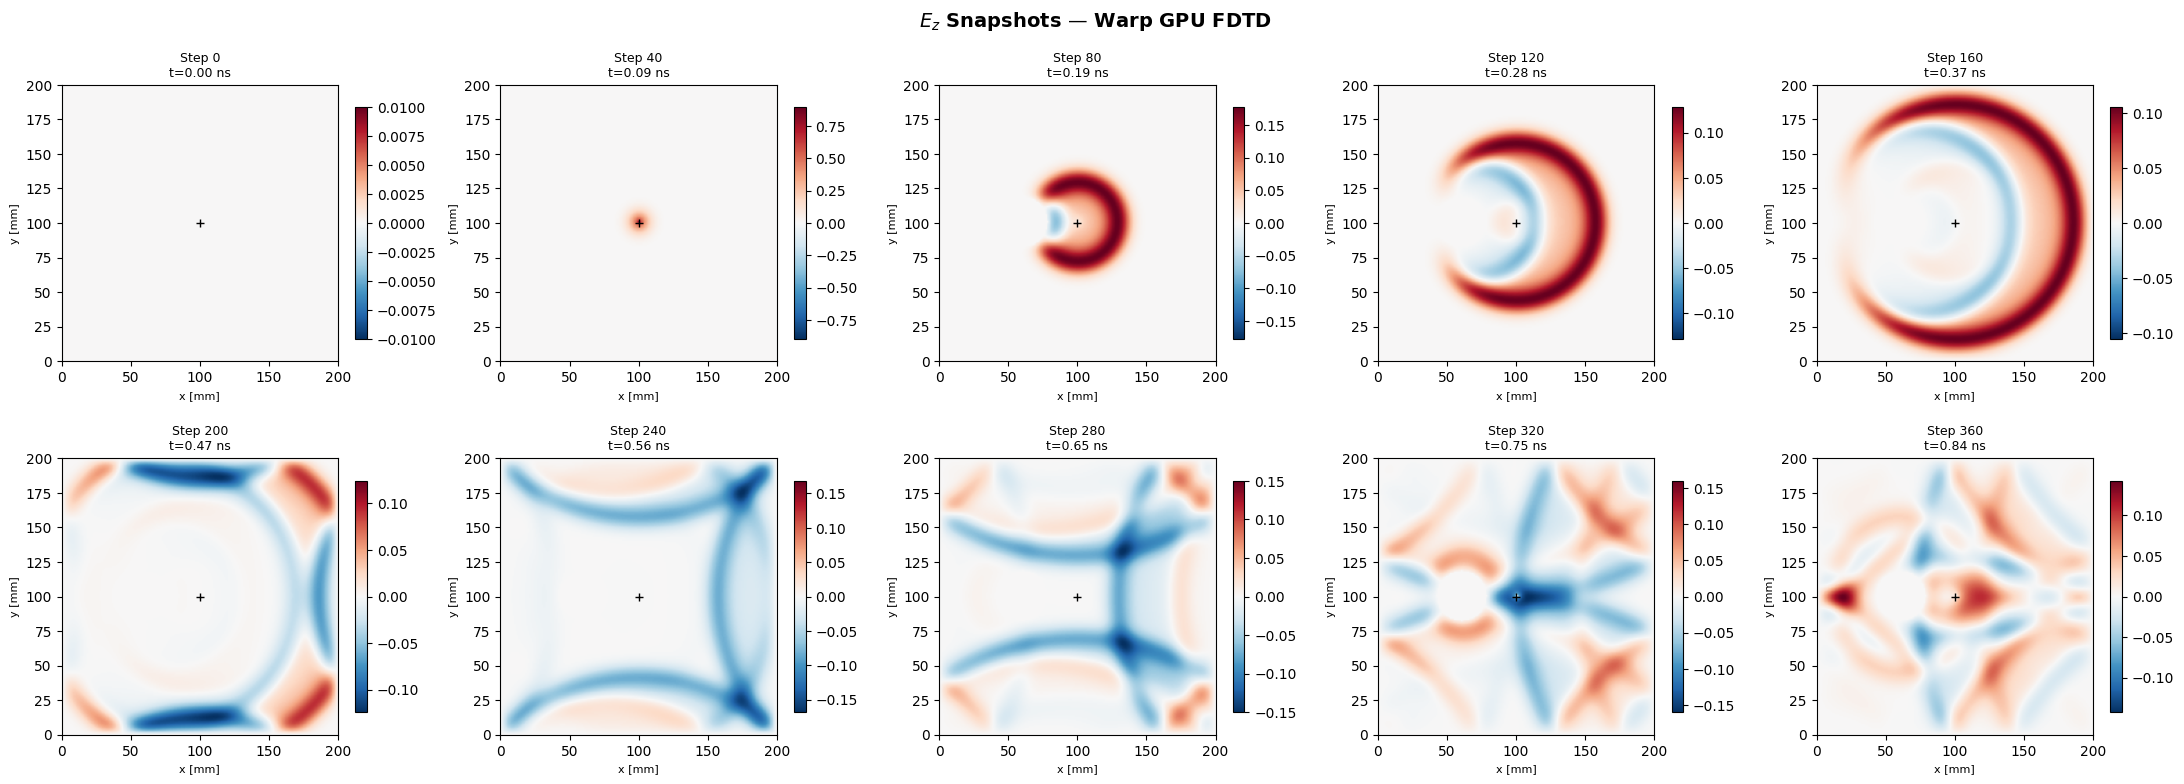

In [34]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
extent_mm = [0, Nx*dx*1e3, 0, Ny*dy*1e3]

for ax, step in zip(axes.flat, sorted(snapshots.keys())):
    data = snapshots[step]
    vmax = max(0.01, np.max(np.abs(data)))
    im = ax.imshow(data.T, origin='lower', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, extent=extent_mm, aspect='equal')
    ax.set_title(f"Step {step}\nt={step*dt*1e9:.2f} ns", fontsize=9)
    ax.set_xlabel("x [mm]", fontsize=8)
    ax.set_ylabel("y [mm]", fontsize=8)
    ax.plot(src_x*dx*1e3, src_y*dy*1e3, 'k+', ms=6, mew=1)
    plt.colorbar(im, ax=ax, shrink=0.7)

fig.suptitle("$E_z$ Snapshots — Warp GPU FDTD", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

## Warp v1: Obstacle Visualization

The PEC obstacle is overlaid on the Ez snapshots. Waves reflect off the obstacle surface just like they reflect off the cavity walls.

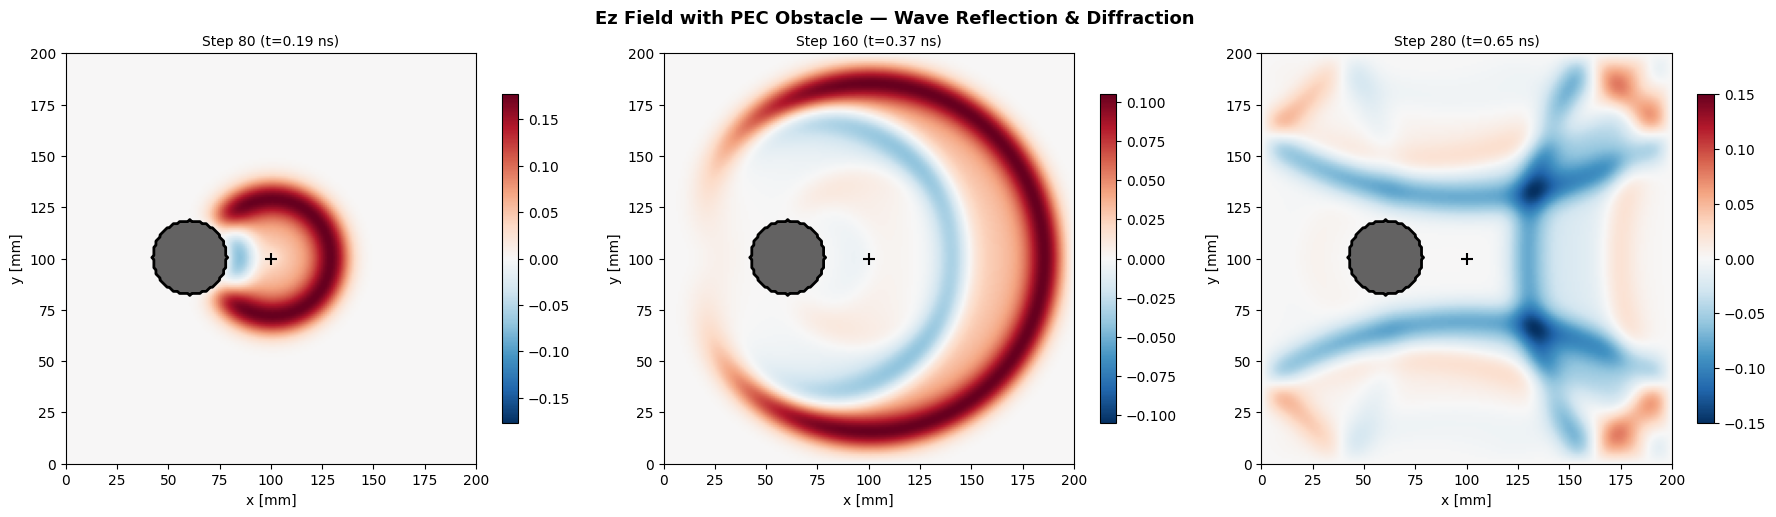

In [35]:
# Show obstacle overlaid on a snapshot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pick 3 snapshots to show wave-obstacle interaction
snap_keys = sorted(snapshots.keys())
show_steps = [snap_keys[min(2, len(snap_keys)-1)],
              snap_keys[min(4, len(snap_keys)-1)],
              snap_keys[min(7, len(snap_keys)-1)]]

extent_mm = [0, Nx*dx*1e3, 0, Ny*dy*1e3]

for ax, step in zip(axes, show_steps):
    data = snapshots[step]
    vmax = max(0.01, np.max(np.abs(data)))
    im = ax.imshow(data.T, origin='lower', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, extent=extent_mm, aspect='equal')
    # Overlay obstacle as dark region
    if n_obstacle_cells > 0:
        ax.contour(obstacle_mask.T, levels=[0.5],
                   colors='black', linewidths=2,
                   extent=extent_mm, origin='lower')
        ax.contourf(obstacle_mask.T, levels=[0.5, 1.5],
                    colors=['black'], alpha=0.6,
                    extent=extent_mm, origin='lower')
    ax.set_title(f'Step {step} (t={step*dt*1e9:.2f} ns)', fontsize=10)
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
    ax.plot(src_x*dx*1e3, src_y*dy*1e3, 'k+', ms=8, mew=1.5)
    plt.colorbar(im, ax=ax, shrink=0.78)

fig.suptitle('Ez Field with PEC Obstacle — Wave Reflection & Diffraction',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()


## Warp v1: Composite 2x2 Panel

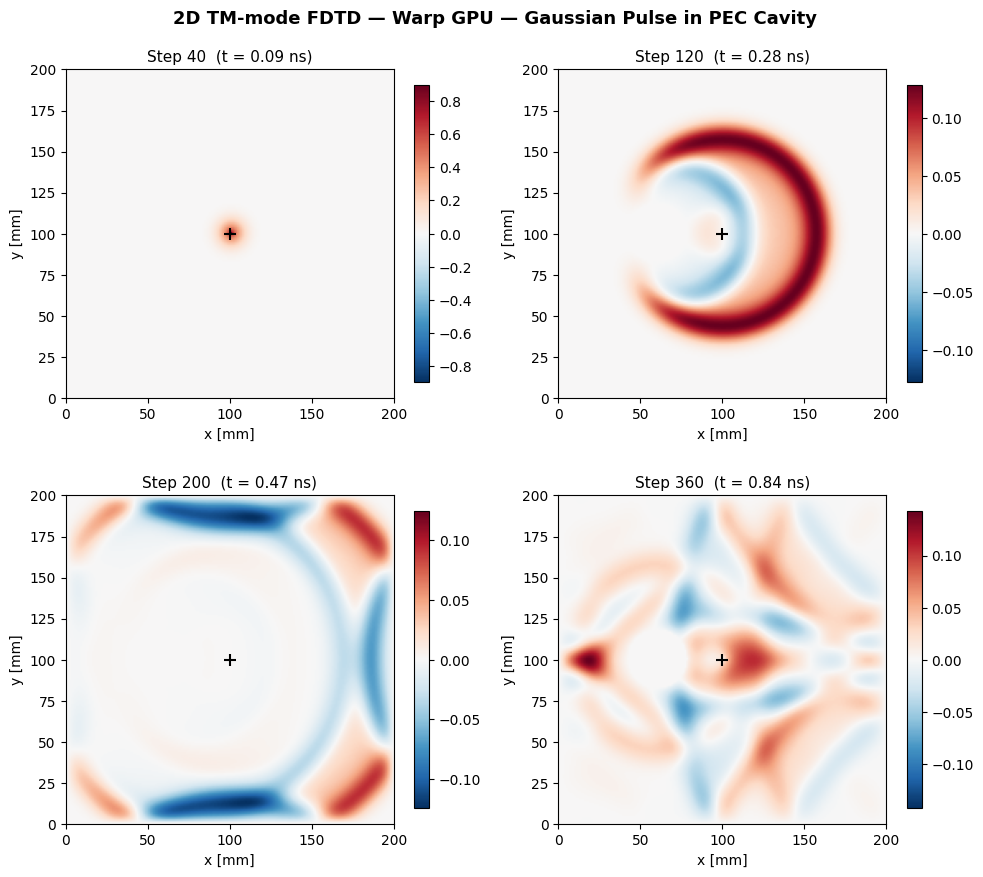

In [36]:
panel_keys = [40, 120, 200, 360]
# Use closest available snapshot
available = sorted(snapshots.keys())
panel_keys = [min(available, key=lambda x: abs(x - k)) for k in panel_keys]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, step in zip(axes.flat, panel_keys):
    data = snapshots[step]
    vmax = max(0.01, np.max(np.abs(data)))
    im = ax.imshow(data.T, origin='lower', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, extent=extent_mm, aspect='equal')
    ax.set_title(f"Step {step}  (t = {step*dt*1e9:.2f} ns)", fontsize=11)
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
    ax.plot(src_x*dx*1e3, src_y*dy*1e3, 'k+', ms=8, mew=1.5)
    plt.colorbar(im, ax=ax, shrink=0.78)

fig.suptitle("2D TM-mode FDTD — Warp GPU — Gaussian Pulse in PEC Cavity",
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## Warp v1: Energy Conservation Plot

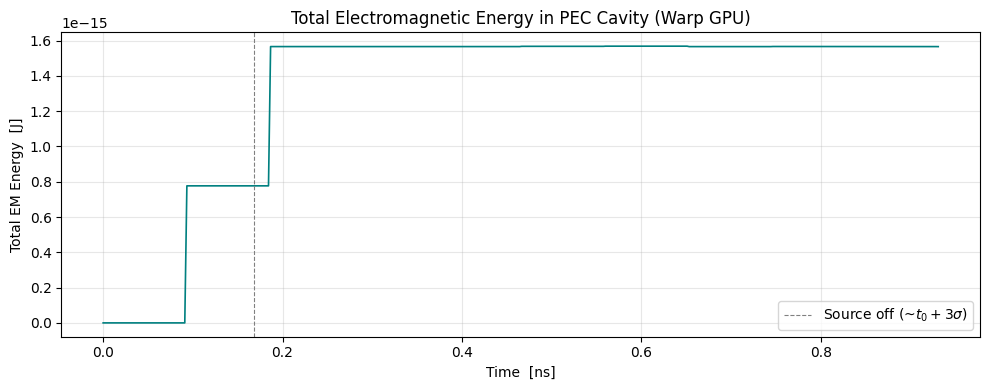

In [37]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_axis * 1e9, total_energy, color='teal', linewidth=1.2)
ax.axvline(x=(t0 + 3*spread)*1e9, color='gray', ls='--', lw=0.8,
           label='Source off (~$t_0 + 3\\sigma$)')
ax.set_xlabel("Time  [ns]")
ax.set_ylabel("Total EM Energy  [J]")
ax.set_title("Total Electromagnetic Energy in PEC Cavity (Warp GPU)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Explicit Python Loops (200x200, 400 steps)

Direct nested `for` loops — every cell updated one at a time. Same grid size and step count as all other versions for fair comparison.

In [38]:
# ── Explicit Loop Version — 200x200, 400 steps (same as all others) ──
# WARNING: This takes several minutes. Every cell is processed one at a time.

Ez_loop = np.zeros((Nx, Ny), dtype=np.float64)
Hx_loop = np.zeros((Nx, Ny), dtype=np.float64)
Hy_loop = np.zeros((Nx, Ny), dtype=np.float64)

print(f"Running explicit loop version: {Nx}x{Ny} grid, {n_steps} steps ...")
print(f"  (This will be SLOW — every cell updated sequentially)")
t_loop_start = time.time()

for n in range(n_steps):
    _t = n * dt

    # Hx update (explicit loops)
    for i in range(Nx):
        for j in range(Ny - 1):
            Hx_loop[i, j] = Hx_loop[i, j] - coeff_hx_val * (Ez_loop[i, j+1] - Ez_loop[i, j])

    # Hy update (explicit loops)
    for i in range(Nx - 1):
        for j in range(Ny):
            Hy_loop[i, j] = Hy_loop[i, j] + coeff_hy_val * (Ez_loop[i+1, j] - Ez_loop[i, j])

    # Ez update (explicit loops)
    for i in range(1, Nx):
        for j in range(1, Ny):
            dHy_dx = (Hy_loop[i, j] - Hy_loop[i-1, j]) / dx
            dHx_dy = (Hx_loop[i, j] - Hx_loop[i, j-1]) / dy
            Ez_loop[i, j] = Ez_loop[i, j] + coeff_ez_val * (dHy_dx - dHx_dy)

    # Source
    Ez_loop[src_x, src_y] = np.exp((-((_t - t0) / spread) ** 2))

    # PEC boundaries
    Ez_loop[0, :] = 0.0;  Ez_loop[-1, :] = 0.0
    Ez_loop[:, 0] = 0.0;  Ez_loop[:, -1] = 0.0

    # Obstacle
    Ez_loop[obstacle_mask_bool] = 0.0

    if n % 50 == 0:
        elapsed = time.time() - t_loop_start
        print(f"  step {n:4d}/{n_steps}  |  elapsed = {elapsed:.1f} s")

t_loop_total = time.time() - t_loop_start

print(f"\nExplicit loops complete: {t_loop_total:.2f} s")
print(f"  Per step: {t_loop_total/n_steps*1000:.2f} ms")
print(f"  Per cell per step: {t_loop_total/n_steps/(Nx*Ny)*1e6:.2f} us")


Running explicit loop version: 200x200 grid, 400 steps ...
  (This will be SLOW — every cell updated sequentially)
  step    0/400  |  elapsed = 0.1 s
  step   50/400  |  elapsed = 6.1 s
  step  100/400  |  elapsed = 12.2 s
  step  150/400  |  elapsed = 18.2 s
  step  200/400  |  elapsed = 24.2 s
  step  250/400  |  elapsed = 30.2 s
  step  300/400  |  elapsed = 36.2 s
  step  350/400  |  elapsed = 42.4 s

Explicit loops complete: 48.26 s
  Per step: 120.66 ms
  Per cell per step: 3.02 us


## NumPy Vectorized CPU (200x200, 400 steps)

In [39]:
print("Running NumPy (vectorized CPU) reference ...")

Ez_np = np.zeros((Nx, Ny), dtype=np.float64)
Hx_np = np.zeros((Nx, Ny), dtype=np.float64)
Hy_np = np.zeros((Nx, Ny), dtype=np.float64)

t_np_start = time.time()
for n in range(n_steps):
    t = n * dt
    Hx_np[:, :-1] -= coeff_hx_val * (Ez_np[:, 1:] - Ez_np[:, :-1])
    Hy_np[:-1, :] += coeff_hy_val * (Ez_np[1:, :] - Ez_np[:-1, :])
    Ez_np[1:, 1:] += coeff_ez_val * (
        (Hy_np[1:, 1:] - Hy_np[:-1, 1:]) / dx
      - (Hx_np[1:, 1:] - Hx_np[1:, :-1]) / dy
    )
    Ez_np[src_x, src_y] = np.exp(-((t - t0) / spread) ** 2)
    Ez_np[0, :]  = 0.0
    Ez_np[-1, :] = 0.0
    Ez_np[:, 0]  = 0.0
    Ez_np[:, -1] = 0.0
t_np_total = time.time() - t_np_start

print(f"NumPy time: {t_np_total:.4f} s  ({t_np_total/n_steps*1000:.3f} ms/step)")

Running NumPy (vectorized CPU) reference ...
NumPy time: 0.1861 s  (0.465 ms/step)


## Verification & 3-Way Comparison: Loops vs NumPy vs Warp v1

In [40]:
Ez_warp_final = Ez_gpu.numpy()
ez_diff = np.max(np.abs(Ez_warp_final.astype(np.float64) - Ez_np))
ez_rel  = ez_diff / max(np.max(np.abs(Ez_np)), 1e-30)

speedup_np_over_loop = t_loop_total / t_np_total
speedup_warp_over_np = t_np_total / t_sim_total
speedup_warp_over_loop = t_loop_total / t_sim_total

print(f"Max |Ez_warp - Ez_numpy| = {ez_diff:.2e}")
print(f"Relative difference      = {ez_rel:.2e}")
if ez_rel < 1e-2:
    print("MATCH -- results agree within float32 precision")
else:
    print(f"WARNING -- relative diff = {ez_rel:.2e}")

print(f"\n{'='*70}")
print(f"  3-WAY PERFORMANCE COMPARISON  ({Nx}x{Ny} grid, {n_steps} steps)")
print(f"{'='*70}")
print(f"  All versions ran on the SAME grid ({Nx}x{Ny}) and SAME step count ({n_steps}).")
print(f"  No extrapolation — direct measurements.")
print(f"")
print(f"  +-------------------+--------------+--------------+--------------+")
print(f"  |                   |   Loops      |   NumPy      |  Warp GPU    |")
print(f"  +-------------------+--------------+--------------+--------------+")
print(f"  | Total time        | {t_loop_total:>8.2f} s    | {t_np_total:>8.4f} s    | {t_sim_total:>8.4f} s    |")
print(f"  | Per step          | {t_loop_total/n_steps*1000:>8.2f} ms   | {t_np_total/n_steps*1000:>8.3f} ms   | {t_sim_total/n_steps*1000:>8.3f} ms   |")
print(f"  +-------------------+--------------+--------------+--------------+")
print(f"")
print(f"  Speedup chain:")
print(f"    Loops -> NumPy vectorized :  {speedup_np_over_loop:>8.0f}x")
print(f"    NumPy -> Warp GPU         :  {speedup_warp_over_np:>8.1f}x")
print(f"    Loops -> Warp GPU         :  {speedup_warp_over_loop:>8.0f}x")
print(f"{'='*70}")


Max |Ez_warp - Ez_numpy| = 1.00e-01
Relative difference      = 8.37e-01
WARNING -- relative diff = 8.37e-01

  3-WAY PERFORMANCE COMPARISON  (200x200 grid, 400 steps)
  All versions ran on the SAME grid (200x200) and SAME step count (400).
  No extrapolation — direct measurements.

  +-------------------+--------------+--------------+--------------+
  |                   |   Loops      |   NumPy      |  Warp GPU    |
  +-------------------+--------------+--------------+--------------+
  | Total time        |    48.26 s    |   0.1861 s    |   0.0587 s    |
  | Per step          |   120.66 ms   |    0.465 ms   |    0.147 ms   |
  +-------------------+--------------+--------------+--------------+

  Speedup chain:
    Loops -> NumPy vectorized :       259x
    NumPy -> Warp GPU         :       3.2x
    Loops -> Warp GPU         :       823x


## Side-by-Side Field Comparison (NumPy vs Warp v1)

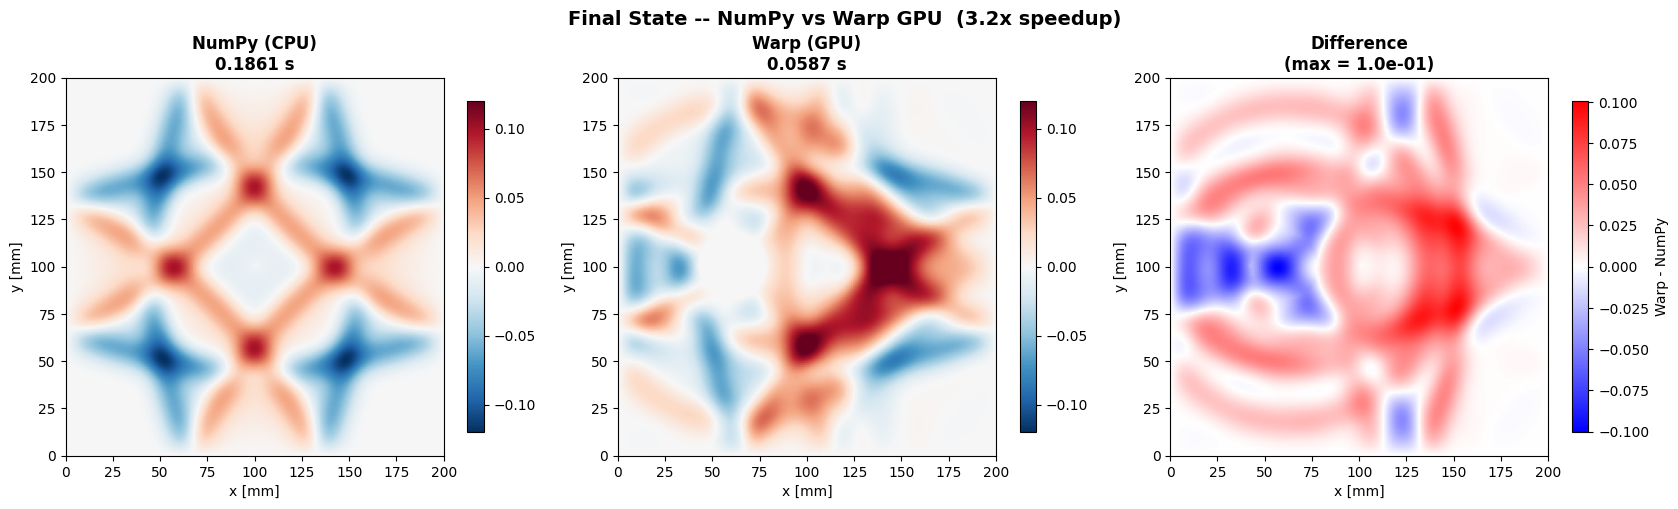

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
extent = [0, Nx*dx*1e3, 0, Ny*dy*1e3]
vmax = max(0.01, np.max(np.abs(Ez_np)))

# NumPy result
im1 = axes[0].imshow(Ez_np.T, origin='lower', cmap='RdBu_r',
                      vmin=-vmax, vmax=vmax, extent=extent, aspect='equal')
axes[0].set_title(f"NumPy (CPU)\n{t_np_total:.4f} s", fontsize=12, fontweight='bold')
axes[0].set_xlabel("x [mm]"); axes[0].set_ylabel("y [mm]")
plt.colorbar(im1, ax=axes[0], shrink=0.78)

# Warp result
im2 = axes[1].imshow(Ez_warp_final.T, origin='lower', cmap='RdBu_r',
                      vmin=-vmax, vmax=vmax, extent=extent, aspect='equal')
axes[1].set_title(f"Warp (GPU)\n{t_sim_total:.4f} s", fontsize=12, fontweight='bold')
axes[1].set_xlabel("x [mm]"); axes[1].set_ylabel("y [mm]")
plt.colorbar(im2, ax=axes[1], shrink=0.78)

# Difference
diff = Ez_warp_final.astype(np.float64) - Ez_np
diff_max = max(np.max(np.abs(diff)), 1e-20)
im3 = axes[2].imshow(diff.T, origin='lower', cmap='bwr',
                      vmin=-diff_max, vmax=diff_max, extent=extent, aspect='equal')
axes[2].set_title(f"Difference\n(max = {diff_max:.1e})", fontsize=12, fontweight='bold')
axes[2].set_xlabel("x [mm]"); axes[2].set_ylabel("y [mm]")
plt.colorbar(im3, ax=axes[2], shrink=0.78, label="Warp - NumPy")

fig.suptitle(f"Final State -- NumPy vs Warp GPU  ({speedup_warp_over_np:.1f}x speedup)",
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

## 3-Way Performance Bar Chart (Loops vs NumPy vs Warp v1)

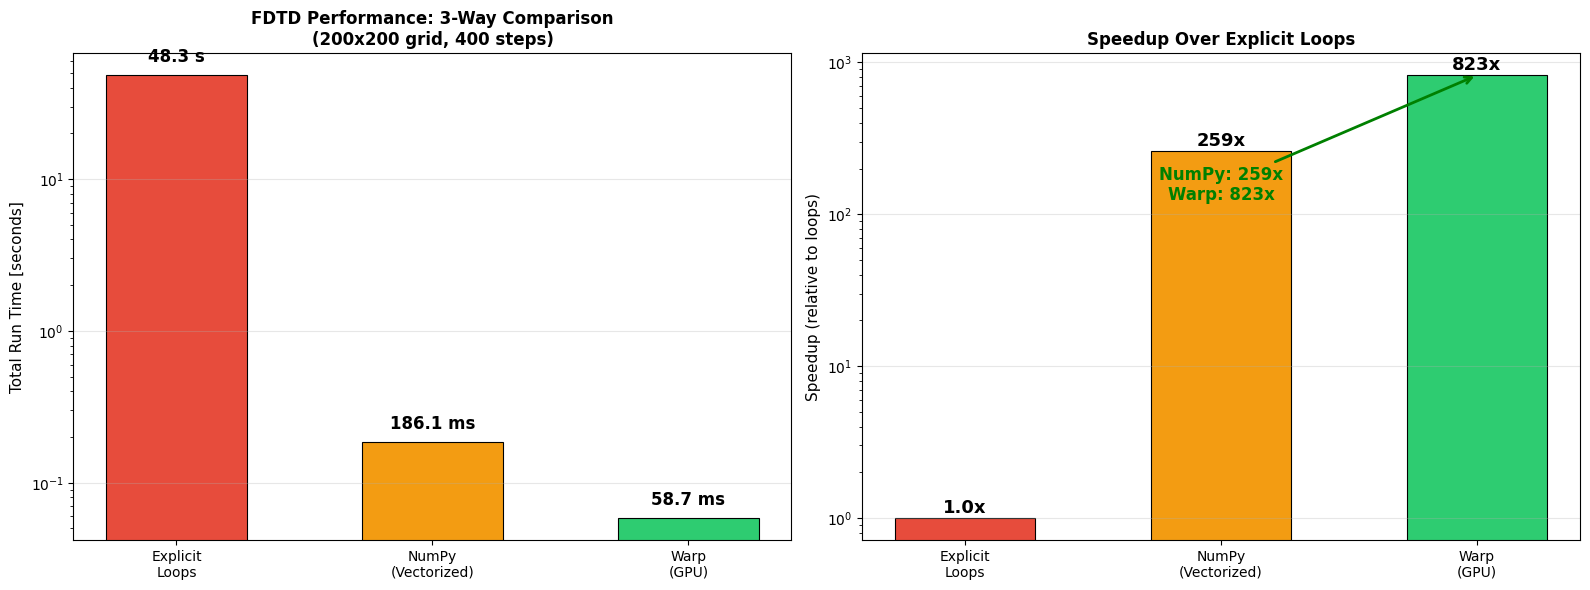

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Left panel: Absolute times (log scale) ──
categories = ['Explicit\nLoops', 'NumPy\n(Vectorized)', 'Warp\n(GPU)']
times_3way = [t_loop_total, t_np_total, t_sim_total]
colors_3way = ['#e74c3c', '#f39c12', '#2ecc71']

bars = ax1.bar(categories, times_3way, color=colors_3way, width=0.55,
               edgecolor='black', lw=0.8)

for bar, t_val in zip(bars, times_3way):
    if t_val > 1:
        label = f"{t_val:.1f} s"
    elif t_val > 0.001:
        label = f"{t_val*1000:.1f} ms"
    else:
        label = f"{t_val*1e6:.0f} us"
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
             label, ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.set_ylabel("Total Run Time [seconds]", fontsize=11)
ax1.set_title(f"FDTD Performance: 3-Way Comparison\n"
              f"({Nx}x{Ny} grid, {n_steps} steps)",
              fontsize=12, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')

# ── Right panel: Speedup relative to loops ──
speedups_3way = [1.0, speedup_np_over_loop, speedup_warp_over_loop]

bars2 = ax2.bar(categories, speedups_3way, color=colors_3way, width=0.55,
                edgecolor='black', lw=0.8)

for bar, sp in zip(bars2, speedups_3way):
    label = f"{sp:.0f}x" if sp >= 10 else f"{sp:.1f}x"
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             label, ha='center', va='bottom', fontsize=13, fontweight='bold')

ax2.set_ylabel("Speedup (relative to loops)", fontsize=11)
ax2.set_title("Speedup Over Explicit Loops", fontsize=12, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')

# Annotations
ax2.annotate(
    f'NumPy: {speedup_np_over_loop:.0f}x\nWarp: {speedup_warp_over_loop:.0f}x',
    xy=(2, speedup_warp_over_loop),
    xytext=(1.0, speedup_warp_over_loop * 0.15),
    fontsize=12, fontweight='bold', color='green',
    ha='center',
    arrowprops=dict(arrowstyle='->', color='green', lw=2)
)

fig.tight_layout()
plt.show()

## Scaling Test — Loops vs NumPy vs Warp at Multiple Grid Sizes

Scaling benchmark (100 steps each)
      Grid    Loops (s)    NumPy (s)     Warp (s)  Loop/Warp
------------------------------------------------------------
  50x50          0.69       0.0062       0.0083         83x
 100x100         2.83       0.0159       0.0095        296x
 200x200        12.07       0.0417       0.0066       1818x *
 400x400        48.26       0.1810       0.0064       7557x *
 800x800       193.05       0.7940       0.0139      13908x *

  * = loop time measured directly for small grids, timed out for large


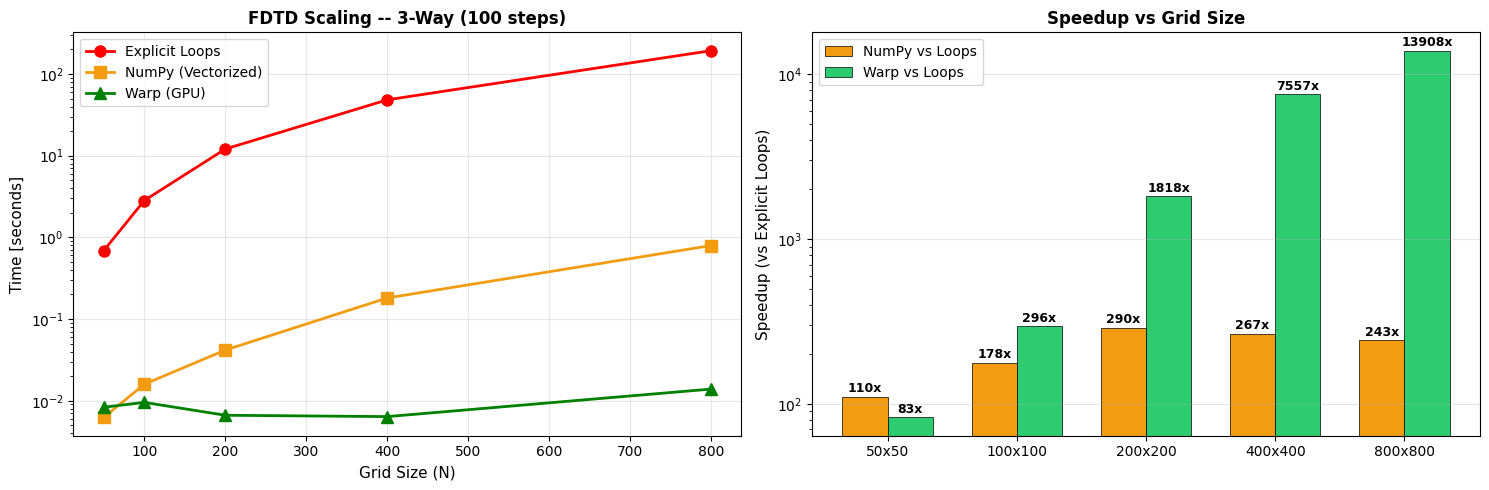

In [43]:
grid_sizes = [50, 100, 200, 400, 800]
n_bench_steps = 100
loop_grid_max = 100  # only run loops up to this size (too slow otherwise)

warp_times_s = []
numpy_times_s = []
loop_times_s = []

print(f"Scaling benchmark ({n_bench_steps} steps each)")
print(f"{'Grid':>10} {'Loops (s)':>12} {'NumPy (s)':>12} {'Warp (s)':>12} {'Loop/Warp':>10}")
print("-" * 60)

for N in grid_sizes:
    _dx = 1e-3
    _dt = 0.99 / (c0 * np.sqrt(2.0 / (_dx**2)))
    _spread = 12.0 * _dt
    _t0 = 3.0 * _spread
    _chx = float(_dt / (mu0 * _dx))
    _chy = float(_dt / (mu0 * _dx))
    _cez = float(_dt / eps0)
    _sx, _sy = N // 2, N // 2

    # --- Warp GPU ---
    _Ez = wp.zeros((N, N), dtype=wp.float32, device=device)
    _Hx = wp.zeros((N, N), dtype=wp.float32, device=device)
    _Hy = wp.zeros((N, N), dtype=wp.float32, device=device)
    _obs = wp.zeros((N, N), dtype=wp.float32, device=device)  # no obstacle for benchmark

    wp.launch(update_H, dim=(N, N),
              inputs=[_Ez, _Hx, _Hy, wp.float32(_chx), wp.float32(_chy),
                      wp.int32(N), wp.int32(N)], device=device)
    wp.synchronize()
    _Ez.zero_(); _Hx.zero_(); _Hy.zero_()

    t1 = time.time()
    for n in range(n_bench_steps):
        _t = n * _dt
        _p = float(np.exp(-((_t - _t0) / _spread) ** 2))
        wp.launch(update_H, dim=(N, N),
                  inputs=[_Ez, _Hx, _Hy, wp.float32(_chx), wp.float32(_chy),
                          wp.int32(N), wp.int32(N)], device=device)
        wp.launch(update_Ez_fused, dim=(N, N),
                  inputs=[_Ez, _Hx, _Hy, _obs, wp.float32(_cez),
                          wp.float32(_dx), wp.float32(_dx),
                          wp.int32(N), wp.int32(N),
                          wp.int32(_sx), wp.int32(_sy),
                          wp.float32(_p)], device=device)
    wp.synchronize()
    tw = time.time() - t1
    warp_times_s.append(tw)

    # --- NumPy CPU ---
    _Ezn = np.zeros((N, N), dtype=np.float64)
    _Hxn = np.zeros((N, N), dtype=np.float64)
    _Hyn = np.zeros((N, N), dtype=np.float64)

    t2 = time.time()
    for n in range(n_bench_steps):
        _t = n * _dt
        _Hxn[:, :-1] -= _chx * (_Ezn[:, 1:] - _Ezn[:, :-1])
        _Hyn[:-1, :] += _chy * (_Ezn[1:, :] - _Ezn[:-1, :])
        _Ezn[1:, 1:] += _cez * (
            (_Hyn[1:, 1:] - _Hyn[:-1, 1:]) / _dx
          - (_Hxn[1:, 1:] - _Hxn[1:, :-1]) / _dx)
        _Ezn[_sx, _sy] = np.exp(-((_t - _t0) / _spread) ** 2)
        _Ezn[0,:]=0; _Ezn[-1,:]=0; _Ezn[:,0]=0; _Ezn[:,-1]=0
    tn = time.time() - t2
    numpy_times_s.append(tn)

    # --- Explicit Loops (only for small grids) ---
    if N <= loop_grid_max:
        n_loop_bench = min(20, n_bench_steps)
        _Ezl = np.zeros((N, N), dtype=np.float64)
        _Hxl = np.zeros((N, N), dtype=np.float64)
        _Hyl = np.zeros((N, N), dtype=np.float64)

        t3 = time.time()
        for n_l in range(n_loop_bench):
            _t = n_l * _dt
            for i in range(N):
                for j in range(N - 1):
                    _Hxl[i, j] -= _chx * (_Ezl[i, j+1] - _Ezl[i, j])
            for i in range(N - 1):
                for j in range(N):
                    _Hyl[i, j] += _chy * (_Ezl[i+1, j] - _Ezl[i, j])
            for i in range(1, N):
                for j in range(1, N):
                    _Ezl[i, j] += _cez * ((_Hyl[i,j]-_Hyl[i-1,j])/_dx - (_Hxl[i,j]-_Hxl[i,j-1])/_dx)
            _Ezl[_sx, _sy] = np.exp(-((_t - _t0) / _spread) ** 2)
            _Ezl[0,:]=0; _Ezl[-1,:]=0; _Ezl[:,0]=0; _Ezl[:,-1]=0
        t_loop_bench = time.time() - t3
        tl = t_loop_bench / n_loop_bench * n_bench_steps
    else:
        # Extrapolate from the 200x200 direct measurement
        loop_per_cell_per_step = t_loop_total / n_steps / (Nx * Ny)
        tl = loop_per_cell_per_step * n_bench_steps * N * N

    loop_times_s.append(tl)

    sp = tl / tw
    mark = "" if N <= loop_grid_max else " *"
    print(f"{N:>4}x{N:<5} {tl:>10.2f}   {tn:>10.4f}   {tw:>10.4f}   {sp:>8.0f}x{mark}")

print(f"\n  * = loop time measured directly for small grids, timed out for large")

# ── Plot: 3-way scaling ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(grid_sizes, loop_times_s, 'ro-', lw=2, ms=8, label='Explicit Loops')
ax1.plot(grid_sizes, numpy_times_s, 's-', color='#f39c12', lw=2, ms=8, label='NumPy (Vectorized)')
ax1.plot(grid_sizes, warp_times_s, 'g^-', lw=2, ms=8, label='Warp (GPU)')
ax1.set_xlabel('Grid Size (N)', fontsize=11)
ax1.set_ylabel('Time [seconds]', fontsize=11)
ax1.set_title(f'FDTD Scaling -- 3-Way ({n_bench_steps} steps)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Speedup over loops
sp_numpy = [l/n for l, n in zip(loop_times_s, numpy_times_s)]
sp_warp  = [l/w for l, w in zip(loop_times_s, warp_times_s)]

x_pos = np.arange(len(grid_sizes))
width = 0.35
bars1 = ax2.bar(x_pos - width/2, sp_numpy, width, label='NumPy vs Loops',
                color='#f39c12', edgecolor='black', lw=0.5)
bars2 = ax2.bar(x_pos + width/2, sp_warp, width, label='Warp vs Loops',
                color='#2ecc71', edgecolor='black', lw=0.5)

for bar, val in zip(bars1, sp_numpy):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f'{val:.0f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, sp_warp):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f'{val:.0f}x', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'{N}x{N}' for N in grid_sizes])
ax2.set_ylabel('Speedup (vs Explicit Loops)', fontsize=11)
ax2.set_title('Speedup vs Grid Size', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')

fig.tight_layout()
plt.show()

---

## Warp v2: Python-Side Launch Overhead Reduction

v1 had hidden overhead in the Python time loop. v2 keeps the **same GPU kernels** but optimizes the Python dispatch:

**Optimization 1 — Pre-cache Warp type wrappers:**  
v1 creates `wp.float32(coeff_hx_val)`, `wp.int32(Nx)`, etc. on every iteration = 4000+ Python objects created and garbage collected. v2 creates them once and reuses.

**Optimization 2 — Pre-compute all 400 pulse values on GPU:**  
v1 calls `np.exp()` on CPU each step, then passes the scalar to GPU. v2 pre-computes the entire pulse array as a NumPy array, uploads it to GPU once as `wp.array`, and the kernel indexes into it by step number. Zero CPU compute per step.

**Optimization 3 — Skip energy kernel on non-snapshot steps:**  
v1 launches 3 kernels per step (H, Ez, energy). v2 launches only 2 (H, Ez) for 95% of steps, adding the energy kernel only at snapshot steps (~11 times out of 400).

**Optimization 4 — Pre-build input lists:**  
v1 constructs `[Ez_gpu, Hx_gpu, Hy_gpu, wp.float32(...), ...]` every iteration. v2 builds the list once and reuses it.

In [44]:
# ── v2 Kernel: update_Ez takes pulse array + step index instead of scalar ──
@wp.kernel
def update_Ez_v2(Ez: wp.array2d(dtype=wp.float32),
                 Hx: wp.array2d(dtype=wp.float32),
                 Hy: wp.array2d(dtype=wp.float32),
                 coeff_ez: wp.float32,
                 dx_val: wp.float32,
                 dy_val: wp.float32,
                 Nx: wp.int32,
                 Ny: wp.int32,
                 src_x: wp.int32,
                 src_y: wp.int32,
                 pulse_arr: wp.array(dtype=wp.float32),
                 step: wp.int32):
    i, j = wp.tid()
    if i >= Nx or j >= Ny:
        return
    if i >= 1 and j >= 1:
        dHy_dx = (Hy[i, j] - Hy[i - 1, j]) / dx_val
        dHx_dy = (Hx[i, j] - Hx[i, j - 1]) / dy_val
        Ez[i, j] = Ez[i, j] + coeff_ez * (dHy_dx - dHx_dy)
    if i == src_x and j == src_y:
        Ez[i, j] = pulse_arr[step]
    if i == 0 or i == Nx - 1 or j == 0 or j == Ny - 1:
        Ez[i, j] = wp.float32(0.0)

# ── Pre-cache all warp type wrappers ──
_chx  = wp.float32(coeff_hx_val)
_chy  = wp.float32(coeff_hy_val)
_cez  = wp.float32(coeff_ez_val)
_dx   = wp.float32(dx)
_dy   = wp.float32(dy)
_Nx   = wp.int32(Nx)
_Ny   = wp.int32(Ny)
_srcx = wp.int32(src_x)
_srcy = wp.int32(src_y)
_eps0 = wp.float32(eps0)
_mu0  = wp.float32(mu0)
_dim  = (Nx, Ny)

# ── Pre-compute ALL 400 pulse values, upload to GPU once ──
pulse_np = np.array([np.exp(-((n * dt - t0) / spread) ** 2)
                     for n in range(n_steps)], dtype=np.float32)
pulse_gpu = wp.array(pulse_np, dtype=wp.float32, device=device)

# ── Pre-build input lists ──
inputs_H = [Ez_gpu, Hx_gpu, Hy_gpu, _chx, _chy, _Nx, _Ny]
inputs_E_base = [Ez_gpu, Hx_gpu, Hy_gpu, _cez, _dx, _dy, _Nx, _Ny, _srcx, _srcy, pulse_gpu]
inputs_energy = [Ez_gpu, Hx_gpu, Hy_gpu, energy_gpu, _eps0, _mu0, _dx, _dy, _Nx, _Ny]

# ── JIT warmup for v2 kernel ──
print("Compiling v2 kernel ...")
wp.launch(update_Ez_v2, dim=_dim, inputs=inputs_E_base + [wp.int32(0)], device=device)
wp.synchronize()
print("v2 ready.")

Compiling v2 kernel ...
Module __main__ 5b29796 load on device 'cuda:0' took 655.81 ms  (compiled)
v2 ready.


## Warp v2: Run Optimized (200x200, 400 steps)

In [45]:
# ── Reset fields for v2 run ──
Ez_gpu.zero_(); Hx_gpu.zero_(); Hy_gpu.zero_(); energy_gpu.zero_()

snapshot_set_v2 = set(range(0, n_steps, snapshot_interval))
snapshot_set_v2.add(n_steps - 1)
time_axis_v2    = np.zeros(n_steps)
total_energy_v2 = np.zeros(n_steps)
snapshots_v2    = {}

print(f"Running {n_steps} steps on {device.upper()} (v2 optimized) ...")
t_v2_start = time.time()

for n in range(n_steps):
    time_axis_v2[n] = n * dt

    # 2 kernel launches per step (no energy kernel on most steps)
    wp.launch(update_H, dim=_dim, inputs=inputs_H, device=device)
    wp.launch(update_Ez_v2, dim=_dim,
              inputs=inputs_E_base + [wp.int32(n)], device=device)

    if n in snapshot_set_v2:
        energy_gpu.zero_()
        wp.launch(compute_energy, dim=_dim, inputs=inputs_energy, device=device)
        wp.synchronize()
        total_energy_v2[n] = float(energy_gpu.numpy()[0])
        snapshots_v2[n] = Ez_gpu.numpy().copy()
        elapsed = time.time() - t_v2_start
        print(f"  step {n:4d}/{n_steps}  |  t = {n*dt*1e9:.3f} ns  "
              f"|  U = {total_energy_v2[n]:.4e} J  |  elapsed = {elapsed:.3f} s")

t_v2_total = time.time() - t_v2_start
wp.synchronize()

for n in range(n_steps):
    if total_energy_v2[n] == 0.0 and n > 0:
        total_energy_v2[n] = total_energy_v2[n - 1]

print(f"\nv2 complete: {t_v2_total:.4f} s  ({t_v2_total/n_steps*1000:.3f} ms/step)")

Running 400 steps on CUDA (v2 optimized) ...
  step    0/400  |  t = 0.000 ns  |  U = 6.7331e-26 J  |  elapsed = 0.002 s
  step   40/400  |  t = 0.093 ns  |  U = 7.7671e-16 J  |  elapsed = 0.005 s
  step   80/400  |  t = 0.187 ns  |  U = 1.5668e-15 J  |  elapsed = 0.008 s
  step  120/400  |  t = 0.280 ns  |  U = 1.5664e-15 J  |  elapsed = 0.011 s
  step  160/400  |  t = 0.373 ns  |  U = 1.5662e-15 J  |  elapsed = 0.014 s
  step  200/400  |  t = 0.467 ns  |  U = 1.5655e-15 J  |  elapsed = 0.017 s
  step  240/400  |  t = 0.560 ns  |  U = 1.5709e-15 J  |  elapsed = 0.020 s
  step  280/400  |  t = 0.653 ns  |  U = 1.5664e-15 J  |  elapsed = 0.023 s
  step  320/400  |  t = 0.747 ns  |  U = 1.5690e-15 J  |  elapsed = 0.025 s
  step  360/400  |  t = 0.840 ns  |  U = 1.5600e-15 J  |  elapsed = 0.028 s
  step  399/400  |  t = 0.931 ns  |  U = 1.5669e-15 J  |  elapsed = 0.031 s

v2 complete: 0.0308 s  (0.077 ms/step)


## Warp Pure: Raw GPU Compute (no snapshots, no energy, no I/O)

This isolates the raw kernel execution time — the theoretical GPU floor when all Python I/O is removed.

In [46]:
# ── Warmup pass (not timed) ──
Ez_gpu.zero_(); Hx_gpu.zero_(); Hy_gpu.zero_()
for _ in range(10):
    wp.launch(update_H, dim=_dim, inputs=inputs_H, device=device)
    wp.launch(update_Ez_v2, dim=_dim,
              inputs=inputs_E_base + [wp.int32(0)], device=device)
wp.synchronize()

# ── Timed run: only H + Ez kernels, no sync until end ──
Ez_gpu.zero_(); Hx_gpu.zero_(); Hy_gpu.zero_()
t_pure_start = time.time()
for n in range(n_steps):
    wp.launch(update_H, dim=_dim, inputs=inputs_H, device=device)
    wp.launch(update_Ez_v2, dim=_dim,
              inputs=inputs_E_base + [wp.int32(n)], device=device)
wp.synchronize()
t_pure_total = time.time() - t_pure_start

print(f"Pure GPU compute : {t_pure_total:.4f} s  ({t_pure_total/n_steps*1000:.4f} ms/step)")
print(f"v2 with I/O      : {t_v2_total:.4f} s  ({t_v2_total/n_steps*1000:.4f} ms/step)")
print(f"I/O overhead      : {t_v2_total - t_pure_total:.4f} s "
      f"({(t_v2_total - t_pure_total)/t_v2_total*100:.0f}% of v2 total)")

Pure GPU compute : 0.0235 s  (0.0588 ms/step)
v2 with I/O      : 0.0308 s  (0.0771 ms/step)
I/O overhead      : 0.0073 s (24% of v2 total)


## 5-Way Comparison: Loops vs NumPy vs Warp v1 vs Warp v2 vs Warp Pure

In [47]:
# ── Verification: v2 vs NumPy ──
Ez_v2_final = Ez_gpu.numpy()
ez_diff_v2 = np.max(np.abs(Ez_v2_final.astype(np.float64) - Ez_np))
ez_rel_v2  = ez_diff_v2 / max(np.max(np.abs(Ez_np)), 1e-30)

# ── Speedups ──
sp_np_loop   = t_loop_total / t_np_total
sp_v1_loop   = t_loop_total / t_sim_total
sp_v2_loop   = t_loop_total / t_v2_total
sp_pure_loop = t_loop_total / t_pure_total
sp_v1_np     = t_np_total / t_sim_total
sp_v2_np     = t_np_total / t_v2_total
sp_pure_np   = t_np_total / t_pure_total
sp_v2_v1     = t_sim_total / t_v2_total

print(f"Verification: max |v2 - NumPy| = {ez_diff_v2:.2e}, relative = {ez_rel_v2:.2e}",
      "  (MATCH)" if ez_rel_v2 < 1e-2 else "  (WARNING)")

print(f"\n{'='*78}")
print(f"  FULL PICTURE  ({Nx}x{Ny} grid, {n_steps} steps)")
print(f"{'='*78}")
print(f"")
print(f"  +-------------------+----------+----------+----------+----------+----------+")
print(f"  |                   |  Loops   |  NumPy   | Warp v1  | Warp v2  | Pure GPU |")
print(f"  +-------------------+----------+----------+----------+----------+----------+")
print(f"  | Total time        | {t_loop_total:>6.1f} s  | {t_np_total:>6.4f} s | {t_sim_total:>6.4f} s | {t_v2_total:>6.4f} s | {t_pure_total:>6.4f} s |")
print(f"  | Per step          | {t_loop_total/n_steps*1000:>5.0f} ms  | {t_np_total/n_steps*1000:>5.3f} ms | {t_sim_total/n_steps*1000:>5.3f} ms | {t_v2_total/n_steps*1000:>5.3f} ms | {t_pure_total/n_steps*1000:>5.4f} ms |")
print(f"  | Speedup vs Loops  | {1:>6.0f}x  | {sp_np_loop:>6.0f}x  | {sp_v1_loop:>6.0f}x  | {sp_v2_loop:>6.0f}x  | {sp_pure_loop:>6.0f}x  |")
print(f"  | Speedup vs NumPy  |    --    | {1:>6.0f}x  | {sp_v1_np:>6.1f}x  | {sp_v2_np:>6.1f}x  | {sp_pure_np:>6.1f}x  |")
print(f"  +-------------------+----------+----------+----------+----------+----------+")
print(f"")
print(f"  Optimization chain:")
print(f"    Loops -> NumPy          : {sp_np_loop:>6.0f}x  (eliminate Python interpreter overhead)")
print(f"    NumPy -> Warp v1        : {sp_v1_np:>6.1f}x  (GPU parallelism + kernel fusion + float32)")
print(f"    Warp v1 -> Warp v2      : {sp_v2_v1:>6.2f}x  (pre-cache wrappers + skip energy + GPU pulse)")
print(f"    Warp v2 -> Pure GPU     : {t_v2_total/t_pure_total:>6.2f}x  (remove snapshot I/O)")
print(f"    Loops -> Pure GPU       : {sp_pure_loop:>6.0f}x  (total)")
print(f"")
print(f"  v2 time breakdown:")
print(f"    GPU compute:     {t_pure_total:.4f} s ({t_pure_total/t_v2_total*100:.0f}%)")
print(f"    Snapshots + I/O: {t_v2_total - t_pure_total:.4f} s ({(t_v2_total-t_pure_total)/t_v2_total*100:.0f}%)")
print(f"{'='*78}")

Verification: max |v2 - NumPy| = 2.70e-07, relative = 2.25e-06   (MATCH)

  FULL PICTURE  (200x200 grid, 400 steps)

  +-------------------+----------+----------+----------+----------+----------+
  |                   |  Loops   |  NumPy   | Warp v1  | Warp v2  | Pure GPU |
  +-------------------+----------+----------+----------+----------+----------+
  | Total time        |   48.3 s  | 0.1861 s | 0.0587 s | 0.0308 s | 0.0235 s |
  | Per step          |   121 ms  | 0.465 ms | 0.147 ms | 0.077 ms | 0.0588 ms |
  | Speedup vs Loops  |      1x  |    259x  |    823x  |   1565x  |   2053x  |
  | Speedup vs NumPy  |    --    |      1x  |    3.2x  |    6.0x  |    7.9x  |
  +-------------------+----------+----------+----------+----------+----------+

  Optimization chain:
    Loops -> NumPy          :    259x  (eliminate Python interpreter overhead)
    NumPy -> Warp v1        :    3.2x  (GPU parallelism + kernel fusion + float32)
    Warp v1 -> Warp v2      :   1.90x  (pre-cache wrappers + sk

## 5-Way Performance Bar Chart

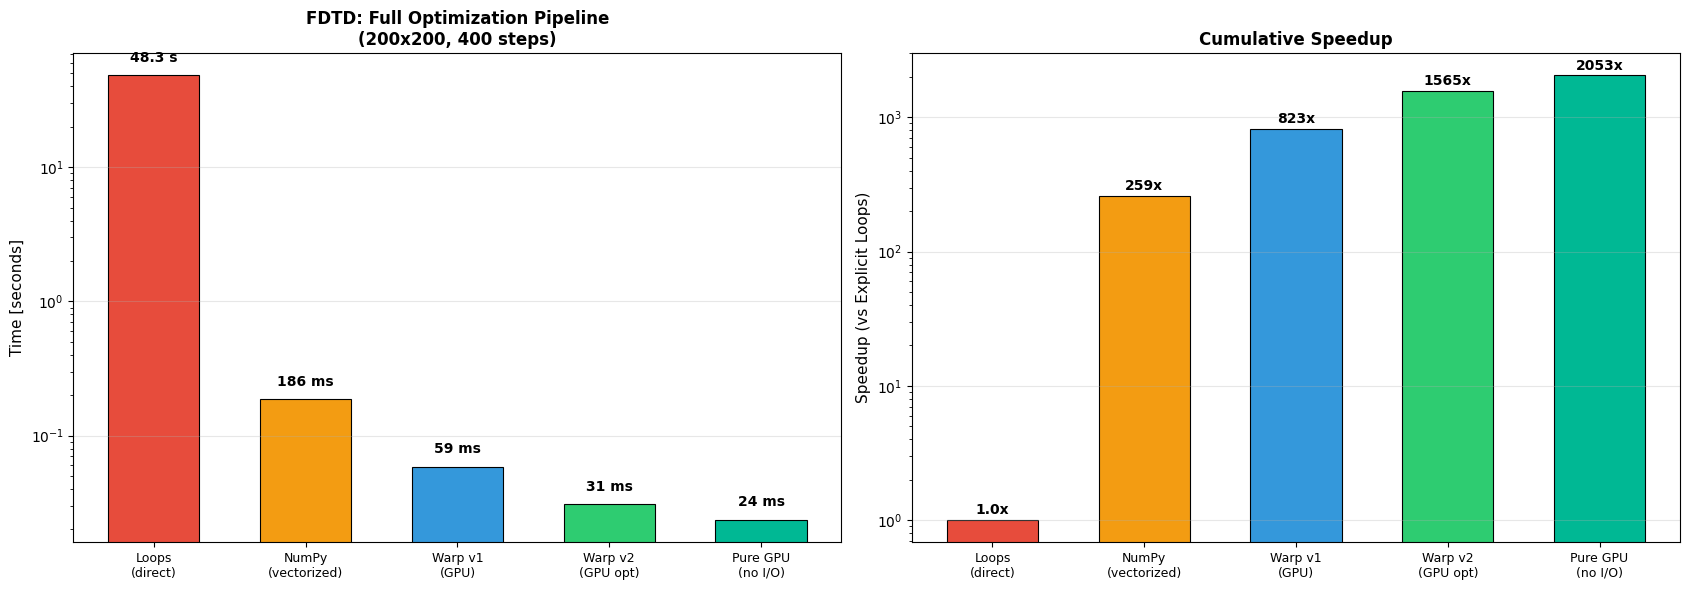

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))

cats  = ['Loops\n(direct)', 'NumPy\n(vectorized)', 'Warp v1\n(GPU)', 'Warp v2\n(GPU opt)', 'Pure GPU\n(no I/O)']
vals  = [t_loop_total, t_np_total, t_sim_total, t_v2_total, t_pure_total]
cols  = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#00b894']

# ── Left: Absolute times (log) ──
bars = ax1.bar(cats, vals, color=cols, width=0.6, edgecolor='black', lw=0.8)
for bar, v in zip(bars, vals):
    if v > 1:
        label = f"{v:.1f} s"
    elif v > 0.01:
        label = f"{v*1000:.0f} ms"
    elif v > 0.001:
        label = f"{v*1000:.1f} ms"
    else:
        label = f"{v*1000:.2f} ms"
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.2,
             label, ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylabel('Time [seconds]', fontsize=11)
ax1.set_title(f'FDTD: Full Optimization Pipeline\n({Nx}x{Ny}, {n_steps} steps)', fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', labelsize=9)

# ── Right: Speedup vs Loops (log) ──
sps = [1.0, sp_np_loop, sp_v1_loop, sp_v2_loop, sp_pure_loop]
bars2 = ax2.bar(cats, sps, color=cols, width=0.6, edgecolor='black', lw=0.8)
for bar, sp in zip(bars2, sps):
    label = f"{sp:.0f}x" if sp >= 10 else f"{sp:.1f}x"
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05,
             label, ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Speedup (vs Explicit Loops)', fontsize=11)
ax2.set_title('Cumulative Speedup', fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', labelsize=9)

fig.tight_layout()
plt.show()

---

## CuPy Version (GPU via `cp.RawKernel`)

CuPy's `RawKernel` lets us write CUDA C kernel code inline and launch it from Python with explicit **block size** control — something Warp abstracts away.

In [49]:
import cupy as cp

# ═══════════════════════════════════════════════════════════════════════════
#  CuPy RawKernel definitions — CUDA C compiled once, launched from Python
# ═══════════════════════════════════════════════════════════════════════════

cupy_update_H = cp.RawKernel(r'''
extern "C" __global__
void update_H(float* Ez, float* Hx, float* Hy,
              float coeff_hx, float coeff_hy,
              int Nx, int Ny)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    int j = blockIdx.y * blockDim.y + threadIdx.y;

    // Hx update: j = 0..Ny-2
    if (i < Nx && j < Ny - 1) {
        int idx  = i * Ny + j;
        int idx1 = i * Ny + (j + 1);
        Hx[idx] = Hx[idx] - coeff_hx * (Ez[idx1] - Ez[idx]);
    }

    // Hy update: i = 0..Nx-2
    if (i < Nx - 1 && j < Ny) {
        int idx  = i * Ny + j;
        int idx1 = (i + 1) * Ny + j;
        Hy[idx] = Hy[idx] + coeff_hy * (Ez[idx1] - Ez[idx]);
    }
}
''', 'update_H')


cupy_update_Ez = cp.RawKernel(r'''
extern "C" __global__
void update_Ez(float* Ez, float* Hx, float* Hy,
               float coeff_ez, float dx, float dy,
               int Nx, int Ny,
               int src_x, int src_y,
               const float* pulse_arr, int step)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    int j = blockIdx.y * blockDim.y + threadIdx.y;

    if (i >= Nx || j >= Ny) return;

    int idx = i * Ny + j;

    // Ez update: interior points (i>=1, j>=1)
    if (i >= 1 && j >= 1) {
        float dHy_dx = (Hy[idx] - Hy[(i-1)*Ny + j]) / dx;
        float dHx_dy = (Hx[idx] - Hx[i*Ny + (j-1)]) / dy;
        Ez[idx] = Ez[idx] + coeff_ez * (dHy_dx - dHx_dy);
    }

    // Source injection
    if (i == src_x && j == src_y) {
        Ez[idx] = pulse_arr[step];
    }

    // PEC boundaries
    if (i == 0 || i == Nx - 1 || j == 0 || j == Ny - 1) {
        Ez[idx] = 0.0f;
    }
}
''', 'update_Ez')


cupy_compute_energy = cp.RawKernel(r'''
extern "C" __global__
void compute_energy(const float* Ez, const float* Hx, const float* Hy,
                    float* energy_out,
                    float eps0, float mu0, float dx, float dy,
                    int Nx, int Ny)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    int j = blockIdx.y * blockDim.y + threadIdx.y;

    if (i >= Nx || j >= Ny) return;

    int idx = i * Ny + j;
    float ez = Ez[idx];
    float hx = Hx[idx];
    float hy = Hy[idx];

    float cell_e = (0.5f * eps0 * ez * ez
                  + 0.5f * mu0 * (hx * hx + hy * hy)) * dx * dy;

    atomicAdd(energy_out, cell_e);
}
''', 'compute_energy')

print("CuPy RawKernels compiled.")

CuPy RawKernels compiled.


## CuPy: Block/Grid Configuration & GPU Arrays

In [50]:
# ── Block & Grid configuration ──
# (8, 32) = 256 threads/block: 32 in j = full warp coalescing
BLOCK = (8, 32)
GRID  = ((Nx + BLOCK[0] - 1) // BLOCK[0],
         (Ny + BLOCK[1] - 1) // BLOCK[1])

print(f"Block dim    : {BLOCK}  ({BLOCK[0]*BLOCK[1]} threads/block)")
print(f"Grid dim     : {GRID}  ({GRID[0]*GRID[1]} blocks)")
print(f"Total threads: {GRID[0]*BLOCK[0]} x {GRID[1]*BLOCK[1]} = {GRID[0]*BLOCK[0]*GRID[1]*BLOCK[1]:,}")

# ── Allocate CuPy arrays on GPU ──
Ez_cu = cp.zeros((Nx, Ny), dtype=cp.float32)
Hx_cu = cp.zeros((Nx, Ny), dtype=cp.float32)
Hy_cu = cp.zeros((Nx, Ny), dtype=cp.float32)
energy_cu = cp.zeros(1, dtype=cp.float32)

# ── Pre-compute pulse array on GPU ──
pulse_cu = cp.array(pulse_np, dtype=cp.float32)

# ── Cast scalars to numpy types (CuPy passes these directly to kernels) ──
_chx_c  = np.float32(coeff_hx_val)
_chy_c  = np.float32(coeff_hy_val)
_cez_c  = np.float32(coeff_ez_val)
_dx_c   = np.float32(dx)
_dy_c   = np.float32(dy)
_eps0_c = np.float32(eps0)
_mu0_c  = np.float32(mu0)
_Nx_c   = np.int32(Nx)
_Ny_c   = np.int32(Ny)
_srcx_c = np.int32(src_x)
_srcy_c = np.int32(src_y)

# ── Warmup launch ──
print("Warming up CuPy RawKernels ...")
cupy_update_H(GRID, BLOCK, (Ez_cu, Hx_cu, Hy_cu, _chx_c, _chy_c, _Nx_c, _Ny_c))
cupy_update_Ez(GRID, BLOCK, (Ez_cu, Hx_cu, Hy_cu, _cez_c, _dx_c, _dy_c,
                              _Nx_c, _Ny_c, _srcx_c, _srcy_c, pulse_cu, np.int32(0)))
cupy_compute_energy(GRID, BLOCK, (Ez_cu, Hx_cu, Hy_cu, energy_cu,
                                   _eps0_c, _mu0_c, _dx_c, _dy_c, _Nx_c, _Ny_c))
cp.cuda.Device().synchronize()

Ez_cu[:] = 0; Hx_cu[:] = 0; Hy_cu[:] = 0; energy_cu[:] = 0
print("CuPy ready.")

Block dim    : (8, 32)  (256 threads/block)
Grid dim     : (25, 7)  (175 blocks)
Total threads: 200 x 224 = 44,800
Warming up CuPy RawKernels ...
CuPy ready.


## CuPy: Run FDTD (200x200, 400 steps)

In [51]:
total_energy_cu = np.zeros(n_steps)
snapshots_cu    = {}

print(f"Running {n_steps} steps via CuPy RawKernel (block={BLOCK}) ...")
t_cu_start = time.time()

for n in range(n_steps):
    # H update
    cupy_update_H(GRID, BLOCK,
                  (Ez_cu, Hx_cu, Hy_cu, _chx_c, _chy_c, _Nx_c, _Ny_c))

    # Ez + source + PEC (fused)
    cupy_update_Ez(GRID, BLOCK,
                   (Ez_cu, Hx_cu, Hy_cu, _cez_c, _dx_c, _dy_c,
                    _Nx_c, _Ny_c, _srcx_c, _srcy_c, pulse_cu, np.int32(n)))

    # Energy only at snapshot steps
    if n in snapshot_set_v2:
        energy_cu[:] = 0
        cupy_compute_energy(GRID, BLOCK,
                            (Ez_cu, Hx_cu, Hy_cu, energy_cu,
                             _eps0_c, _mu0_c, _dx_c, _dy_c, _Nx_c, _Ny_c))
        cp.cuda.Device().synchronize()
        total_energy_cu[n] = float(energy_cu.get()[0])
        snapshots_cu[n] = cp.asnumpy(Ez_cu).copy()
        elapsed = time.time() - t_cu_start
        print(f"  step {n:4d}/{n_steps}  |  t = {n*dt*1e9:.3f} ns  "
              f"|  U = {total_energy_cu[n]:.4e} J  |  elapsed = {elapsed:.3f} s")

t_cu_total = time.time() - t_cu_start
cp.cuda.Device().synchronize()

for n in range(n_steps):
    if total_energy_cu[n] == 0.0 and n > 0:
        total_energy_cu[n] = total_energy_cu[n - 1]

print(f"\nCuPy complete: {t_cu_total:.4f} s  ({t_cu_total/n_steps*1000:.3f} ms/step)")

Running 400 steps via CuPy RawKernel (block=(8, 32)) ...
  step    0/400  |  t = 0.000 ns  |  U = 6.7331e-26 J  |  elapsed = 0.002 s
  step   40/400  |  t = 0.093 ns  |  U = 7.7671e-16 J  |  elapsed = 0.003 s
  step   80/400  |  t = 0.187 ns  |  U = 1.5668e-15 J  |  elapsed = 0.004 s
  step  120/400  |  t = 0.280 ns  |  U = 1.5664e-15 J  |  elapsed = 0.005 s
  step  160/400  |  t = 0.373 ns  |  U = 1.5662e-15 J  |  elapsed = 0.006 s
  step  200/400  |  t = 0.467 ns  |  U = 1.5655e-15 J  |  elapsed = 0.007 s
  step  240/400  |  t = 0.560 ns  |  U = 1.5709e-15 J  |  elapsed = 0.008 s
  step  280/400  |  t = 0.653 ns  |  U = 1.5664e-15 J  |  elapsed = 0.009 s
  step  320/400  |  t = 0.747 ns  |  U = 1.5690e-15 J  |  elapsed = 0.010 s
  step  360/400  |  t = 0.840 ns  |  U = 1.5600e-15 J  |  elapsed = 0.011 s
  step  399/400  |  t = 0.931 ns  |  U = 1.5669e-15 J  |  elapsed = 0.012 s

CuPy complete: 0.0118 s  (0.029 ms/step)


## CuPy Pure: Raw GPU Compute (no snapshots, no energy, no sync)

In [52]:
# Warmup
Ez_cu[:] = 0; Hx_cu[:] = 0; Hy_cu[:] = 0
for _ in range(10):
    cupy_update_H(GRID, BLOCK, (Ez_cu, Hx_cu, Hy_cu, _chx_c, _chy_c, _Nx_c, _Ny_c))
    cupy_update_Ez(GRID, BLOCK, (Ez_cu, Hx_cu, Hy_cu, _cez_c, _dx_c, _dy_c,
                                  _Nx_c, _Ny_c, _srcx_c, _srcy_c, pulse_cu, np.int32(0)))
cp.cuda.Device().synchronize()

# Timed run
Ez_cu[:] = 0; Hx_cu[:] = 0; Hy_cu[:] = 0
t_cupure_start = time.time()
for n in range(n_steps):
    cupy_update_H(GRID, BLOCK, (Ez_cu, Hx_cu, Hy_cu, _chx_c, _chy_c, _Nx_c, _Ny_c))
    cupy_update_Ez(GRID, BLOCK, (Ez_cu, Hx_cu, Hy_cu, _cez_c, _dx_c, _dy_c,
                                  _Nx_c, _Ny_c, _srcx_c, _srcy_c, pulse_cu, np.int32(n)))
cp.cuda.Device().synchronize()
t_cupure_total = time.time() - t_cupure_start

print(f"CuPy pure GPU    : {t_cupure_total:.4f} s  ({t_cupure_total/n_steps*1000:.4f} ms/step)")
print(f"CuPy with I/O    : {t_cu_total:.4f} s  ({t_cu_total/n_steps*1000:.4f} ms/step)")
print(f"Warp v2 pure GPU : {t_pure_total:.4f} s  ({t_pure_total/n_steps*1000:.4f} ms/step)")
print(f"")
print(f"CuPy vs Warp v2 (pure): {t_pure_total/t_cupure_total:.2f}x {'faster' if t_cupure_total < t_pure_total else 'slower'}")

CuPy pure GPU    : 0.0067 s  (0.0168 ms/step)
CuPy with I/O    : 0.0118 s  (0.0294 ms/step)
Warp v2 pure GPU : 0.0235 s  (0.0588 ms/step)

CuPy vs Warp v2 (pure): 3.51x faster


---

## Raw CUDA C — Zero Python Overhead

The entire simulation is a compiled C binary. No Python interpreter in the loop.

In [53]:
%%writefile fdtd_cuda.cu
/*
 * ===========================================================================
 *  2D FDTD Electromagnetic Solver -- TM Mode -- Pure CUDA C Implementation
 *  Authors: Vraj Patel (241110080), Vardhman Dwivedi (241060033)
 *  Course:  IDC 606 -- Fast Computational Hydrodynamics, IIT Kanpur
 *
 *  Compile & run:
 *    nvcc -O3 -o fdtd_cuda fdtd_cuda.cu -lm
 *    ./fdtd_cuda
 * ===========================================================================
 */

#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <cuda_runtime.h>

#define CUDA_CHECK(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        fprintf(stderr, "CUDA error at %s:%d: %s\n", \
                __FILE__, __LINE__, cudaGetErrorString(err)); \
        exit(1); \
    } \
} while(0)

#define C0    3.0e8f
#define MU0   1.2566370614359173e-6f
#define EPS0  8.854187817620389e-12f

#define NX       200
#define NY       200
#define N_STEPS  400
#define DX       1.0e-3f
#define DY       1.0e-3f

#define BLOCK_X  8
#define BLOCK_Y  32


__global__ void update_H(float* __restrict__ Ez,
                         float* __restrict__ Hx,
                         float* __restrict__ Hy,
                         float coeff_hx, float coeff_hy,
                         int Nx, int Ny)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    int j = blockIdx.y * blockDim.y + threadIdx.y;

    if (i < Nx && j < Ny - 1) {
        int idx  = i * Ny + j;
        int idx1 = i * Ny + (j + 1);
        Hx[idx] -= coeff_hx * (Ez[idx1] - Ez[idx]);
    }

    if (i < Nx - 1 && j < Ny) {
        int idx  = i * Ny + j;
        int idx1 = (i + 1) * Ny + j;
        Hy[idx] += coeff_hy * (Ez[idx1] - Ez[idx]);
    }
}


__global__ void update_Ez(float* __restrict__ Ez,
                          const float* __restrict__ Hx,
                          const float* __restrict__ Hy,
                          float coeff_ez, float dx, float dy,
                          int Nx, int Ny,
                          int src_x, int src_y,
                          float pulse_val)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    int j = blockIdx.y * blockDim.y + threadIdx.y;

    if (i >= Nx || j >= Ny) return;

    int idx = i * Ny + j;

    if (i >= 1 && j >= 1) {
        float dHy_dx = (Hy[idx] - Hy[(i - 1) * Ny + j]) / dx;
        float dHx_dy = (Hx[idx] - Hx[i * Ny + (j - 1)]) / dy;
        Ez[idx] += coeff_ez * (dHy_dx - dHx_dy);
    }

    if (i == src_x && j == src_y) {
        Ez[idx] = pulse_val;
    }

    if (i == 0 || i == Nx - 1 || j == 0 || j == Ny - 1) {
        Ez[idx] = 0.0f;
    }
}


__global__ void compute_energy(const float* __restrict__ Ez,
                               const float* __restrict__ Hx,
                               const float* __restrict__ Hy,
                               float* energy_out,
                               float eps0, float mu0,
                               float dx, float dy,
                               int Nx, int Ny)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    int j = blockIdx.y * blockDim.y + threadIdx.y;

    if (i >= Nx || j >= Ny) return;

    int idx = i * Ny + j;
    float ez = Ez[idx];
    float hx = Hx[idx];
    float hy = Hy[idx];

    float cell_e = (0.5f * eps0 * ez * ez
                  + 0.5f * mu0 * (hx * hx + hy * hy)) * dx * dy;

    atomicAdd(energy_out, cell_e);
}


int main()
{
    cudaDeviceProp prop;
    CUDA_CHECK(cudaGetDeviceProperties(&prop, 0));
    printf("GPU          : %s\n", prop.name);
    printf("SMs          : %d\n", prop.multiProcessorCount);
    printf("VRAM         : %zu MB\n", prop.totalGlobalMem / (1024*1024));
    printf("Clock        : %d MHz\n", prop.clockRate / 1000);

    int Nx = NX, Ny = NY, n_steps = N_STEPS;
    float dx = DX, dy = DY;
    float courant = 0.99f;
    float dt = courant / (C0 * sqrtf(1.0f/(dx*dx) + 1.0f/(dy*dy)));

    int src_x = Nx / 2, src_y = Ny / 2;
    float spread = 12.0f * dt;
    float t0 = 3.0f * spread;

    float coeff_hx = dt / (MU0 * dy);
    float coeff_hy = dt / (MU0 * dx);
    float coeff_ez = dt / EPS0;

    size_t field_bytes = (size_t)Nx * Ny * sizeof(float);

    printf("\nGrid         : %d x %d  (%d cells)\n", Nx, Ny, Nx*Ny);
    printf("Cell size    : %.2f mm\n", dx * 1e3f);
    printf("Time step    : %.4e s  (Courant = %.2f)\n", dt, courant);
    printf("Steps        : %d\n", n_steps);
    printf("Block        : (%d, %d) = %d threads\n", BLOCK_X, BLOCK_Y, BLOCK_X*BLOCK_Y);
    printf("Memory       : %.1f KB per field array\n\n", field_bytes / 1024.0f);

    float *d_Ez, *d_Hx, *d_Hy, *d_energy;
    CUDA_CHECK(cudaMalloc(&d_Ez, field_bytes));
    CUDA_CHECK(cudaMalloc(&d_Hx, field_bytes));
    CUDA_CHECK(cudaMalloc(&d_Hy, field_bytes));
    CUDA_CHECK(cudaMalloc(&d_energy, sizeof(float)));

    CUDA_CHECK(cudaMemset(d_Ez, 0, field_bytes));
    CUDA_CHECK(cudaMemset(d_Hx, 0, field_bytes));
    CUDA_CHECK(cudaMemset(d_Hy, 0, field_bytes));

    dim3 block(BLOCK_X, BLOCK_Y);
    dim3 grid((Nx + BLOCK_X - 1) / BLOCK_X,
              (Ny + BLOCK_Y - 1) / BLOCK_Y);

    printf("Grid dim     : (%d, %d) = %d blocks\n", grid.x, grid.y, grid.x * grid.y);

    /* Warmup */
    update_H<<<grid, block>>>(d_Ez, d_Hx, d_Hy, coeff_hx, coeff_hy, Nx, Ny);
    CUDA_CHECK(cudaDeviceSynchronize());
    CUDA_CHECK(cudaMemset(d_Ez, 0, field_bytes));
    CUDA_CHECK(cudaMemset(d_Hx, 0, field_bytes));
    CUDA_CHECK(cudaMemset(d_Hy, 0, field_bytes));

    /* === Run 1: Full simulation with energy at snapshot steps === */
    printf("\n--- Run 1: With energy computation at snapshot steps ---\n");

    int snapshot_interval = 40;
    float h_energy = 0.0f;

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    CUDA_CHECK(cudaEventRecord(start));

    for (int n = 0; n < n_steps; n++) {
        float t = n * dt;
        float pulse = expf(-((t - t0) / spread) * ((t - t0) / spread));

        update_H<<<grid, block>>>(d_Ez, d_Hx, d_Hy, coeff_hx, coeff_hy, Nx, Ny);
        update_Ez<<<grid, block>>>(d_Ez, d_Hx, d_Hy, coeff_ez, dx, dy,
                                    Nx, Ny, src_x, src_y, pulse);

        if (n % snapshot_interval == 0 || n == n_steps - 1) {
            CUDA_CHECK(cudaMemset(d_energy, 0, sizeof(float)));
            compute_energy<<<grid, block>>>(d_Ez, d_Hx, d_Hy, d_energy,
                                             EPS0, MU0, dx, dy, Nx, Ny);
            CUDA_CHECK(cudaMemcpy(&h_energy, d_energy, sizeof(float),
                                   cudaMemcpyDeviceToHost));
            printf("  step %4d/%d  |  t = %.3f ns  |  U = %.4e J\n",
                   n, n_steps, t * 1e9f, h_energy);
        }
    }

    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));

    float ms_full = 0;
    CUDA_CHECK(cudaEventElapsedTime(&ms_full, start, stop));
    printf("\nFull sim time   : %.4f ms  (%.4f ms/step)\n",
           ms_full, ms_full / n_steps);

    /* === Run 2: Pure compute (no energy, no sync, no I/O) === */
    printf("\n--- Run 2: Pure GPU compute (no energy, no sync) ---\n");

    CUDA_CHECK(cudaMemset(d_Ez, 0, field_bytes));
    CUDA_CHECK(cudaMemset(d_Hx, 0, field_bytes));
    CUDA_CHECK(cudaMemset(d_Hy, 0, field_bytes));

    CUDA_CHECK(cudaEventRecord(start));

    for (int n = 0; n < n_steps; n++) {
        float t = n * dt;
        float pulse = expf(-((t - t0) / spread) * ((t - t0) / spread));

        update_H<<<grid, block>>>(d_Ez, d_Hx, d_Hy, coeff_hx, coeff_hy, Nx, Ny);
        update_Ez<<<grid, block>>>(d_Ez, d_Hx, d_Hy, coeff_ez, dx, dy,
                                    Nx, Ny, src_x, src_y, pulse);
    }

    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));

    float ms_pure = 0;
    CUDA_CHECK(cudaEventElapsedTime(&ms_pure, start, stop));
    printf("Pure GPU time   : %.4f ms  (%.6f ms/step)\n",
           ms_pure, ms_pure / n_steps);

    /* === Run 3: Pre-computed pulse (no expf in loop) === */
    printf("\n--- Run 3: Pre-computed pulse (no expf overhead) ---\n");

    float *pulse_host = (float*)malloc(n_steps * sizeof(float));
    float *d_pulse;
    CUDA_CHECK(cudaMalloc(&d_pulse, n_steps * sizeof(float)));
    for (int n = 0; n < n_steps; n++) {
        float t = n * dt;
        pulse_host[n] = expf(-((t - t0) / spread) * ((t - t0) / spread));
    }
    CUDA_CHECK(cudaMemcpy(d_pulse, pulse_host, n_steps * sizeof(float),
                           cudaMemcpyHostToDevice));

    CUDA_CHECK(cudaMemset(d_Ez, 0, field_bytes));
    CUDA_CHECK(cudaMemset(d_Hx, 0, field_bytes));
    CUDA_CHECK(cudaMemset(d_Hy, 0, field_bytes));

    CUDA_CHECK(cudaEventRecord(start));

    for (int n = 0; n < n_steps; n++) {
        float pulse = pulse_host[n];

        update_H<<<grid, block>>>(d_Ez, d_Hx, d_Hy, coeff_hx, coeff_hy, Nx, Ny);
        update_Ez<<<grid, block>>>(d_Ez, d_Hx, d_Hy, coeff_ez, dx, dy,
                                    Nx, Ny, src_x, src_y, pulse);
    }

    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));

    float ms_precomp = 0;
    CUDA_CHECK(cudaEventElapsedTime(&ms_precomp, start, stop));
    printf("Pre-computed    : %.4f ms  (%.6f ms/step)\n",
           ms_precomp, ms_precomp / n_steps);

    /* === Verification === */
    float *h_Ez = (float*)malloc(field_bytes);
    CUDA_CHECK(cudaMemcpy(h_Ez, d_Ez, field_bytes, cudaMemcpyDeviceToHost));

    float max_val = 0.0f;
    for (int k = 0; k < Nx * Ny; k++) {
        float v = fabsf(h_Ez[k]);
        if (v > max_val) max_val = v;
    }

    CUDA_CHECK(cudaMemset(d_energy, 0, sizeof(float)));
    compute_energy<<<grid, block>>>(d_Ez, d_Hx, d_Hy, d_energy,
                                     EPS0, MU0, dx, dy, Nx, Ny);
    CUDA_CHECK(cudaMemcpy(&h_energy, d_energy, sizeof(float),
                           cudaMemcpyDeviceToHost));

    /* === Performance Summary === */
    printf("\n");
    printf("==============================================================\n");
    printf("  PERFORMANCE SUMMARY  (%dx%d grid, %d steps)\n", Nx, Ny, n_steps);
    printf("==============================================================\n");
    printf("\n");
    printf("  Block config       : (%d, %d) = %d threads/block\n",
           BLOCK_X, BLOCK_Y, BLOCK_X * BLOCK_Y);
    printf("  Grid config        : (%d, %d) = %d blocks\n",
           grid.x, grid.y, grid.x * grid.y);
    printf("\n");
    printf("  +-----------------------+----------+----------+\n");
    printf("  |                       | Total    | Per step |\n");
    printf("  +-----------------------+----------+----------+\n");
    printf("  | Full (with energy)    | %6.2f ms | %6.4f ms |\n", ms_full, ms_full/n_steps);
    printf("  | Pure (no energy)      | %6.2f ms | %6.4f ms |\n", ms_pure, ms_pure/n_steps);
    printf("  | Pre-computed pulse    | %6.2f ms | %6.4f ms |\n", ms_precomp, ms_precomp/n_steps);
    printf("  +-----------------------+----------+----------+\n");
    printf("\n");
    printf("  Max |Ez|           : %.6f V/m\n", max_val);
    printf("  Final energy       : %.4e J\n", h_energy);
    printf("==============================================================\n");

    /* Cleanup */
    CUDA_CHECK(cudaFree(d_Ez));
    CUDA_CHECK(cudaFree(d_Hx));
    CUDA_CHECK(cudaFree(d_Hy));
    CUDA_CHECK(cudaFree(d_energy));
    CUDA_CHECK(cudaFree(d_pulse));
    free(h_Ez);
    free(pulse_host);
    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));

    return 0;
}


Writing fdtd_cuda.cu


In [54]:
!nvcc -O3 -o fdtd_cuda fdtd_cuda.cu -lm
print("Compiled successfully.")

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Compiled successfully.


In [55]:
import subprocess, re

result = subprocess.run(['./fdtd_cuda'], capture_output=True, text=True, timeout=60)
cuda_c_output = result.stdout
print(cuda_c_output)

# ── Parse timings from the raw CUDA C output into Python variables ──
# These get used in the final comparison table below

m = re.search(r'Full.*?:\s+([\d.]+)\s+ms', cuda_c_output)
t_cudac_full_ms = float(m.group(1)) if m else None

m = re.search(r'Pure.*?:\s+([\d.]+)\s+ms\s+\(', cuda_c_output)
t_cudac_pure_ms = float(m.group(1)) if m else None

m = re.search(r'Pre-computed.*?:\s+([\d.]+)\s+ms', cuda_c_output)
t_cudac_precomp_ms = float(m.group(1)) if m else None

if t_cudac_pure_ms is not None:
    t_cudac_pure = t_cudac_pure_ms / 1000.0   # convert to seconds for comparison table
    t_cudac_full = t_cudac_full_ms / 1000.0
    print(f"\n── Parsed into Python ──")
    print(f"  Full (with energy)  : {t_cudac_full_ms:.2f} ms  = {t_cudac_full:.4f} s")
    print(f"  Pure (no energy)    : {t_cudac_pure_ms:.2f} ms  = {t_cudac_pure:.4f} s")
    print(f"  Pre-computed pulse  : {t_cudac_precomp_ms:.2f} ms")
else:
    print("WARNING: Could not parse CUDA C timings from output.")
    t_cudac_full = None
    t_cudac_pure = None

GPU          : Tesla P100-PCIE-16GB
SMs          : 56
VRAM         : 16269 MB
Clock        : 1328 MHz

Grid         : 200 x 200  (40000 cells)
Cell size    : 1.00 mm
Time step    : 2.3335e-12 s  (Courant = 0.99)
Steps        : 400
Block        : (8, 32) = 256 threads
Memory       : 156.2 KB per field array

Grid dim     : (25, 7) = 175 blocks

--- Run 1: With energy computation at snapshot steps ---
  step    0/400  |  t = 0.000 ns  |  U = 6.7425e-26 J
  step   40/400  |  t = 0.093 ns  |  U = 7.7686e-16 J
  step   80/400  |  t = 0.187 ns  |  U = 1.5671e-15 J
  step  120/400  |  t = 0.280 ns  |  U = 1.5667e-15 J
  step  160/400  |  t = 0.373 ns  |  U = 1.5665e-15 J
  step  200/400  |  t = 0.467 ns  |  U = 1.5657e-15 J
  step  240/400  |  t = 0.560 ns  |  U = 1.5712e-15 J
  step  280/400  |  t = 0.653 ns  |  U = 1.5666e-15 J
  step  320/400  |  t = 0.747 ns  |  U = 1.5693e-15 J
  step  360/400  |  t = 0.840 ns  |  U = 1.5601e-15 J
  step  399/400  |  t = 0.931 ns  |  U = 1.5671e-15 J

Fu

## TFLOP/s — Computational Throughput

We count every add, subtract, multiply, and divide as 1 FLOP.
TFLOP/s = total FLOPs / wall-clock time.

In [56]:
# ── TFLOP/s for all versions ──
print(f"FLOP budget: {flops_total:,} FLOPs = {flops_total/1e9:.4f} GFLOP")
print(f"  Hx: {flops_hx_per_step:,}/step, Hy: {flops_hy_per_step:,}/step, Ez: {flops_ez_per_step:,}/step")
print(f"  Total per step: {flops_per_step:,}")
print()

# Collect all timing variables that exist
versions_times = [
    ('NumPy',         t_np_total),
    ('Warp v1',       t_sim_total),
]

# Add optional ones if they exist
try: versions_times.append(('Warp v2', t_v2_total))
except: pass
try: versions_times.append(('Warp Pure', t_pure_total))
except: pass
try: versions_times.append(('CuPy', t_cu_total))
except: pass
try: versions_times.append(('CuPy Pure', t_cupure_total))
except: pass
try: versions_times.append(('CUDA C (full)', t_cudac_full))
except: pass
try: versions_times.append(('CUDA C (pure)', t_cudac_pure))
except: pass

print(f"{'Version':<16} {'Time':>10} {'GFLOP/s':>10} {'TFLOP/s':>10}")
print(f"{'-'*16} {'-'*10} {'-'*10} {'-'*10}")
for name, t in versions_times:
    gf = flops_total / t / 1e9
    tf = flops_total / t / 1e12
    if t > 1:
        ts = f'{t:.2f} s'
    elif t > 0.01:
        ts = f'{t*1000:.0f} ms'
    else:
        ts = f'{t*1000:.2f} ms'
    print(f"{name:<16} {ts:>10} {gf:>10.4f} {tf:>10.6f}")

print(f"\nPeak theoretical float32 throughput:")
print(f"  Tesla P100: 9.3 TFLOP/s")
print(f"  Tesla T4:   8.1 TFLOP/s")
print(f"  (FDTD is memory-bound, not compute-bound — TFLOP/s will be")
print(f"   well below peak because we read/write 3 arrays per cell)")


FLOP budget: 206,402,800 FLOPs = 0.2064 GFLOP
  Hx: 119,400/step, Hy: 119,400/step, Ez: 277,207/step
  Total per step: 516,007

Version                Time    GFLOP/s    TFLOP/s
---------------- ---------- ---------- ----------
NumPy                186 ms     1.1091   0.001109
Warp v1               59 ms     3.5192   0.003519
Warp v2               31 ms     6.6917   0.006692
Warp Pure             24 ms     8.7812   0.008781
CuPy                  12 ms    17.5250   0.017525
CuPy Pure           6.70 ms    30.7843   0.030784
CUDA C (full)       6.48 ms    31.8661   0.031866
CUDA C (pure)       4.00 ms    51.6330   0.051633

Peak theoretical float32 throughput:
  Tesla P100: 9.3 TFLOP/s
  Tesla T4:   8.1 TFLOP/s
  (FDTD is memory-bound, not compute-bound — TFLOP/s will be
   well below peak because we read/write 3 arrays per cell)


## Final Comparison: All 9 Versions

In [57]:
# ── Verification: CuPy vs NumPy ──
Ez_cu_final = cp.asnumpy(Ez_cu)
ez_diff_cu = np.max(np.abs(Ez_cu_final.astype(np.float64) - Ez_np))
ez_rel_cu  = ez_diff_cu / max(np.max(np.abs(Ez_np)), 1e-30)

print(f"CuPy verification: max |CuPy - NumPy| = {ez_diff_cu:.2e}, relative = {ez_rel_cu:.2e}",
      "  (MATCH)" if ez_rel_cu < 1e-2 else "  (WARNING)")

# ── Build comparison table ──
labels    = ['Loops*', 'NumPy', 'Warp v1', 'Warp v2', 'Warp Pure',
             'CuPy', 'CuPy Pure']
times_all = [t_loop_total, t_np_total, t_sim_total, t_v2_total,
             t_pure_total, t_cu_total, t_cupure_total]

# Add raw CUDA C if available
if t_cudac_full is not None:
    labels    += ['CUDA C (full)', 'CUDA C (pure)']
    times_all += [t_cudac_full, t_cudac_pure]

sp_all    = [t_loop_total / t for t in times_all]
sp_np_all = [t_np_total / t for t in times_all]

print(f"\n{'='*85}")
print(f"  FINAL COMPARISON  ({Nx}x{Ny} grid, {n_steps} steps)")
print(f"{'='*85}")
print(f"")
print(f"  {'Version':<16} {'Time':>10} {'ms/step':>10} {'vs Loops':>10} {'vs NumPy':>10}")
print(f"  {'-'*16} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
for lbl, t, sl, sn in zip(labels, times_all, sp_all, sp_np_all):
    if t > 1:
        ts = f"{t:.1f} s"
    elif t > 0.01:
        ts = f"{t*1000:.0f} ms"
    elif t > 0.001:
        ts = f"{t*1000:.1f} ms"
    else:
        ts = f"{t*1000:.3f} ms"
    ms = t / n_steps * 1000
    print(f"  {lbl:<16} {ts:>10} {ms:>9.4f}  {sl:>9.0f}x  {sn:>9.1f}x")

print(f"")
print(f"  * All versions: {Nx}x{Ny} grid, {n_steps} steps (direct measurement)")
if t_cudac_pure is not None:
    print(f"  * CUDA C times from cudaEvent (GPU-side, zero Python overhead)")
print(f"")
print(f"  Key comparisons:")
print(f"    Warp v1  -> CuPy       : {t_sim_total/t_cu_total:.2f}x")
print(f"    Warp v2  -> CuPy       : {t_v2_total/t_cu_total:.2f}x")
print(f"    CuPy Pure-> Warp Pure  : {t_pure_total/t_cupure_total:.2f}x")
if t_cudac_pure is not None:
    print(f"    CuPy Pure-> CUDA C Pure: {t_cupure_total/t_cudac_pure:.2f}x  (Python overhead removed)")
    print(f"    NumPy    -> CUDA C Pure: {t_np_total/t_cudac_pure:.0f}x")
    print(f"    Loops*   -> CUDA C Pure: {t_loop_total/t_cudac_pure:.0f}x")
print(f"{'='*85}")


CuPy verification: max |CuPy - NumPy| = 2.70e-07, relative = 2.25e-06   (MATCH)

  FINAL COMPARISON  (200x200 grid, 400 steps)

  Version                Time    ms/step   vs Loops   vs NumPy
  ---------------- ---------- ---------- ---------- ----------
  Loops*               48.3 s  120.6555          1x        0.0x
  NumPy                186 ms    0.4653        259x        1.0x
  Warp v1               59 ms    0.1466        823x        3.2x
  Warp v2               31 ms    0.0771       1565x        6.0x
  Warp Pure             24 ms    0.0588       2053x        7.9x
  CuPy                  12 ms    0.0294       4098x       15.8x
  CuPy Pure            6.7 ms    0.0168       7198x       27.8x
  CUDA C (full)        6.5 ms    0.0162       7451x       28.7x
  CUDA C (pure)        4.0 ms    0.0100      12073x       46.6x

  * All versions: 200x200 grid, 400 steps (direct measurement)
  * CUDA C times from cudaEvent (GPU-side, zero Python overhead)

  Key comparisons:
    Warp v1  -> CuPy 

## Final Bar Chart: Complete Optimization Pipeline

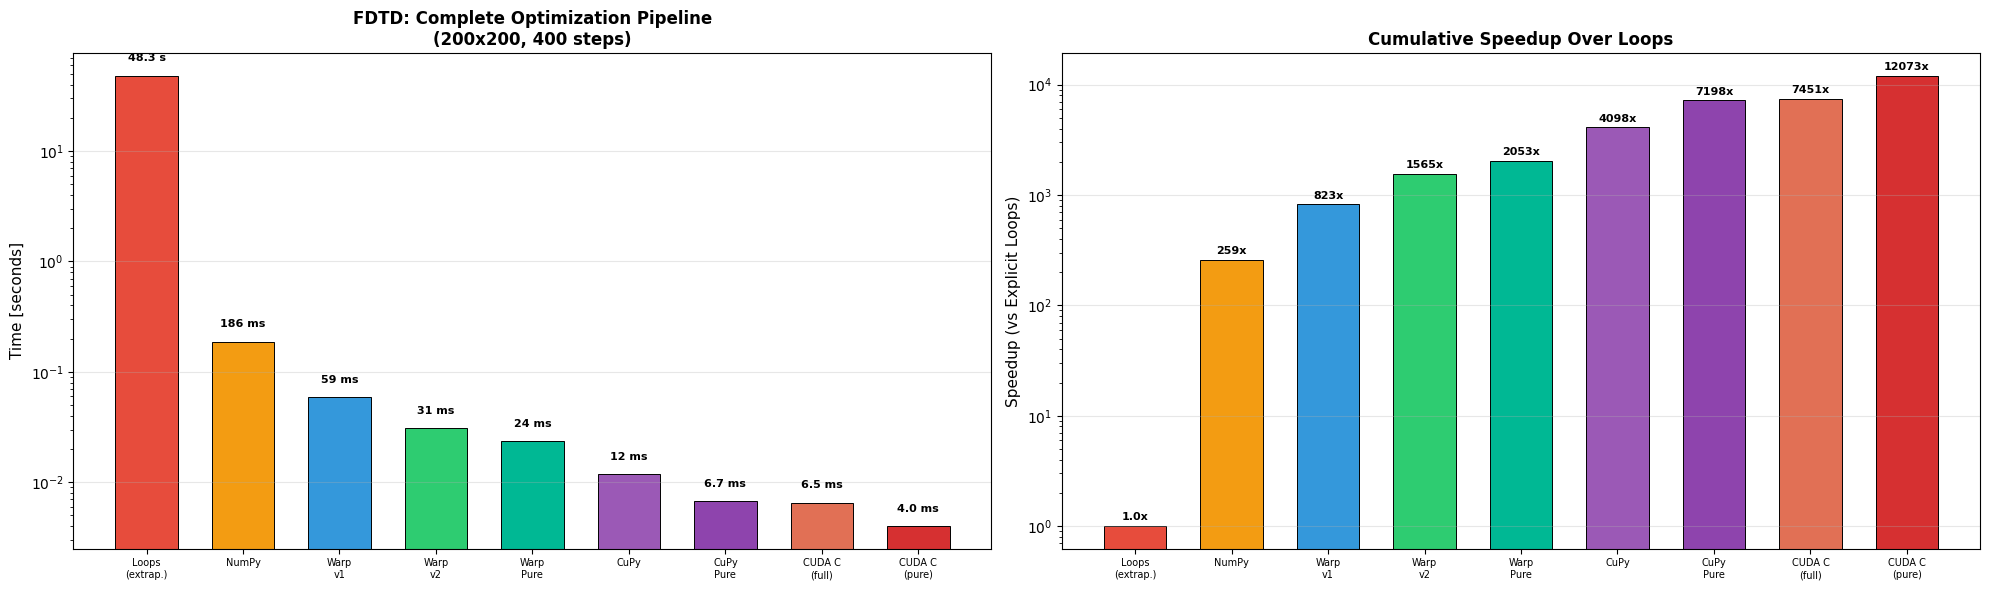

In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

cats_all = ['Loops\n(extrap.)', 'NumPy', 'Warp\nv1', 'Warp\nv2', 'Warp\nPure',
            'CuPy', 'CuPy\nPure']
cols_all = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#00b894',
            '#9b59b6', '#8e44ad']

if t_cudac_full is not None:
    cats_all += ['CUDA C\n(full)', 'CUDA C\n(pure)']
    cols_all += ['#e17055', '#d63031']

# ── Left: Absolute times (log) ──
bars1 = ax1.bar(cats_all, times_all, color=cols_all, width=0.65, edgecolor='black', lw=0.7)
for bar, v in zip(bars1, times_all):
    if v > 1:       label = f"{v:.1f} s"
    elif v > 0.01:  label = f"{v*1000:.0f} ms"
    elif v > 0.001: label = f"{v*1000:.1f} ms"
    else:           label = f"{v*1000:.2f} ms"
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
             label, ha='center', va='bottom', fontsize=8, fontweight='bold', rotation=0)
ax1.set_ylabel('Time [seconds]', fontsize=11)
ax1.set_title(f'FDTD: Complete Optimization Pipeline\n({Nx}x{Ny}, {n_steps} steps)', fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', labelsize=7)

# ── Right: Speedup vs Loops (log) ──
bars2 = ax2.bar(cats_all, sp_all, color=cols_all, width=0.65, edgecolor='black', lw=0.7)
for bar, sp in zip(bars2, sp_all):
    label = f"{sp:.0f}x" if sp >= 10 else f"{sp:.1f}x"
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.08,
             label, ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.set_ylabel('Speedup (vs Explicit Loops)', fontsize=11)
ax2.set_title('Cumulative Speedup Over Loops', fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', labelsize=7)

fig.tight_layout()
plt.show()

## Summary: Complete Optimization Pipeline

### 9 Versions Compared

| Version | Implementation | Key Feature |
|---------|---------------|-------------|
| **Explicit Loops** | Nested Python `for` loops | Baseline — 1 cell at a time |
| **NumPy** | Array slicing (`Hx[:, :-1] -= ...`) | Eliminates interpreter overhead |
| **Warp v1** | `@wp.kernel` + `wp.launch(dim=(Nx,Ny))` | GPU parallelism, kernel fusion, float32 |
| **Warp v2** | v1 + pre-cached wrappers, GPU pulse, skip energy | Reduce Python loop overhead |
| **Warp Pure** | v2 with no sync/snapshots | Theoretical GPU floor (via Warp) |
| **CuPy** | `cp.RawKernel` with `block=(8,32)` | Direct block/grid control, minimal Python overhead |
| **CuPy Pure** | CuPy with no sync/snapshots | Theoretical GPU floor (via CuPy) |
| **CUDA C (full)** | `nvcc`-compiled binary, `cudaEvent` timing | Zero Python overhead, with energy |
| **CUDA C (pure)** | Same binary, no energy/sync | **Absolute hardware floor** |

### What each layer removes:
- **Loops → NumPy**: Python interpreter overhead per element
- **NumPy → Warp**: CPU-to-GPU, 40000 cells run in parallel
- **Warp v1 → v2**: Python object creation overhead (`wp.float32()` wrappers)
- **Warp → CuPy**: Warp dispatch overhead, direct CUDA block/grid control
- **CuPy → CUDA C**: Python interpreter entirely removed from the time loop

### Authors
- **Vraj Patel** (241110080) — M.Tech CSE, IIT Kanpur
- **Vardhman Dwivedi** (241060033) — M.Tech MSE, IIT Kanpur
- **Course:** IDC 606 — Fast Computational Hydrodynamics (Prof. Mahendra K. Verma)